# Stateful Analysis

## Packages

In [1]:
%pip install beautifulsoup4 scikit_posthocs publicsuffix2 adblockparser pingouin tldextract statannotations pandas numpy matplotlib seaborn scipy requests tqdm



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
    # imports

%matplotlib inline
import pandas as pd
import numpy as np
import sqlite3
import os
from bs4 import BeautifulSoup as bs
import re
from functools import reduce
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
sns.set_theme()
import requests
import warnings
import scipy.stats
import scikit_posthocs as sp
from publicsuffix2 import PublicSuffixList
import time
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pingouin as pg
import tldextract
import copy


from tqdm import tqdm
from adblockparser import AdblockRules
import csv
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor

from statannotations.Annotator import Annotator

psl = PublicSuffixList()
warnings.filterwarnings('ignore')
# %config Completer.use_jedi = False

/root/miniconda3/envs/openwpm/lib/python3.9/site-packages/tldextract/cli.py:8: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Initial variables

In [12]:
# # plots configs

# plt.rc('text', usetex=True)

plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 2
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 3000
plt.rcParams["figure.autolayout"] = True
plt.rcParams["text.usetex"] = True
plt.rcParams['figure.figsize'] = 3.35,7.03
single_col_width = 3.6 * 0.9
double_col_width = 7.8 * 0.9
sns.set_style("white")
# plt.rc('text', usetex=False)      # disable LaTeX
# plt.rcParams["text.usetex"] = False
# plt.rcParams['font.size'] = 9
# plt.rcParams['axes.linewidth'] = 2
# plt.rcParams["savefig.bbox"] = "tight"
# plt.rcParams["savefig.dpi"] = 3000
# plt.rcParams["figure.autolayout"] = True
# sns.set_style("white")

In [19]:
# Minimal initialization for single location analysis

# Directory paths
FIG_DIR = './files/figs'
INPUT_DIR = './files/inputs'  # Fixed the typo
BU_DIR = './files/backups'

# Optional: location mapping (only if needed later)
server_to_loc = {'eu-central-1': "Germany"}

In [5]:
# initializing vars

AWS_names = ['eu-central-1']
local_names = []
servers_to_fetch = AWS_names

server_to_loc = {'eu-central-1': "Germany" }
loc_to_server = {'Germany': "eu-central-1"}
locations = ['Germany']
EU_locs = ['Germany']
# nonEU_locs = ['US East', 'US West', 'India', 'Brazil', 'South Africa', 'Australia']


NUM_BATCH = 1

run_to_folder = {'js_first': 'js_first_20k'}



js_runs = ["js_first"]


FIG_DIR = './files/figs'
INPUT_DIR = './files/inputs'
BU_DIR = './files/backups'

In [6]:
runs = {}

## Setup functions

In [7]:
# printing utility functions

def show_detection_status(run_cat="desktop"):
    for name, aws in runs[run_cat].AWS_map.items():
        df = aws.visits
        if 'banners' in df:
            print('{:14} detect {:4} and {:4} websites with banners and CMP respectively out of {:4} entries in DB.'.format(name, df[df.banners>0].shape[0], df[df.__tcfapi==1].shape[0], df.shape[0]))

def show_run_status(run_cat="desktop"):
    for name, aws in runs[run_cat].AWS_map.items():
        df = aws.visits
        if 'banners' in df:
            print('{:14} reachable: {:3}, selenium timeout: {:3}, unreachable: {:3}, exception during banner detection {:3}.'.format(name, df[df.status==0].shape[0], df[df.status==1].shape[0], df[df.status==2].shape[0], df[df.status==-1].shape[0]))

In [8]:
# logical utility functions

def awstoserver(aws):
    return f"inet-gc-p-{aws}.dyn.mpi-klsb.mpg.de"

def make_suffix(string):
    return "_" + string.replace('-', '_')

def add_suffix(df, name, base_column=["visit_id", "domain"], inplace=False):
    suffix = make_suffix(name)
    if inplace:
        df = df.add_suffix(suffix).rename(columns=dict(zip([f"{bc}{suffix}" for bc in base_column], base_column)), inplace=True)
        return df
    else:
        temp = df.add_suffix(suffix)
        return temp.rename(columns=dict(zip([f"{bc}{suffix}" for bc in base_column], base_column)), inplace=False)

def get_db_path(server_name, batch=-1, run_name="desktop", folder_order=False):
    if server_name in local_names:
        server_url = "inet-"+server_name+".mpi-inf.mpg.de"
    else:
        server_url = "inet-gc-p-"+server_name+".dyn.mpi-klsb.mpg.de"
    data_dir = "data"
    # run_folder = run_to_folder[run_name]
    run_folder = run_to_folder.get(run_name, run_name)
    dir_list = os.listdir(f"{data_dir}/{run_folder}/{server_url}/")
    if folder_order:
        if r'.ipynb_checkpoints' in dir_list :
            dir_list.remove(r'.ipynb_checkpoints')
        dir_list.sort()
        try :
            data_file = dir_list[batch]
        except Exception as e :
            pass
    else:

        SP_list = [int(directory.split("SP")[1]) for directory in dir_list]
        SP_list = list(set(SP_list))
        SP_list.sort()
        data_file = dir_list[-1]
        if batch != -1:
            top = str(SP_list[batch])
            folder_names = [name for name in dir_list if "SP" in name and top == name.split("SP")[1]]
            data_file = folder_names[-1]
    path = f"{data_dir}/{run_folder}/{server_url}/{data_file}/crawl-data.sqlite"
    return path

def get_last_visit(visits):  # not a good implementation since the last one can be unrechable by OpenWPM
    last_visit = visits[visits.visit_id<OFFSET_ACCEPT-2].visit_id.max() + 1
    return last_visit

def to_bool(df, cmp_mod, x):
    if cmp_mod == 1:
        return df == x
    elif cmp_mod == -1:
        return df != x

def do_all(dfs, operand, cmp_mod, to_cmp):
    if operand == '&':
        res = reduce(lambda x, y: x&y, [to_bool(df,cmp_mod,to_cmp) for df in dfs])
    if operand == '|':
        res = reduce(lambda x, y: x|y, [to_bool(df,cmp_mod,to_cmp) for df in dfs])
    if operand == '+':
        res = reduce(lambda x, y: x+y, [to_bool(df,cmp_mod,to_cmp) for df in dfs])

    return res

# return dataframe contains all vantage points togethers. Column names appended by "_AWS_NAME"
def merge_dfs(AWS_list, table='visits'):
    dfs = []
    for aws in AWS_list:
        aws_name = aws.name
        df = aws.table_map[table]
        df = add_suffix(df, aws_name)
        dfs.append(df)
    merged = reduce(lambda  left,right: pd.merge(left, right, how='outer', left_on=['visit_id','domain'], right_on=['visit_id','domain']), dfs)
    return merged

def get_column(df, base_column, aws_name):
    cl = base_column + make_suffix(aws_name)
    return df[cl]

def get_columns(df, base_column, aws_names):
    cls = [base_column + make_suffix(name) for name in aws_names]
    return df[cls]

def get_AWS_obj(run, location):
    return runs[run].AWS_map[loc_to_server[location]]

# return only rechables crawls
# status=1 means loaded websites, if it is the case for all VP then we considdefer ot
# TODO: these should be changed, here we assume runs with same visit_id should consider together which is wrong.
# However it is too rare that not all of the crawls for the same domain in one VP behave differently. (see appendix.1)
def pulish_with_status(merged, aws_names=[]):
    rd = merged[get_columns(merged, 'status', aws_names).any(axis=1).eq(0)]
    return rd

def append_series(servers, table, column):
    dfs = pd.Series()
    flag = False
    for server in servers:
        aws_name = server.name
        df = server.table_map[table][column]
        if not flag:
            flag = True
            dfs = df
            continue
        dfs = dfs.append(df, ignore_index=True)
    return dfs
# d = append_series(runs['mobile-sc'].AWS_list, 'visits', 'ttw')


In [9]:
# classes

# AWS class is for each VP and contains all variable needed to handle VP charachtristics like location, different DBs and etc.
class Server:
    def __init__(self, name=None, visits=None,javascript_cookies=None, javascript=None):
        table_map = {}
        self.name = name
        self.location = server_to_loc[name]
        self.visits = visits
        self.javascript_cookies = javascript_cookies
        self.javascript = javascript
        table_map["visits"] = self.visits
        table_map["javascript_cookies"] = self.javascript_cookies
        table_map["javascript"] = self.javascript
        self.table_map = table_map

class Run:
    def __init__(self, name=None, server_map=None, AWS_list=None):
        self.name = name
        self.server_map = server_map
        self.AWS_list = AWS_list
        self.AWS_names = self.server_map.keys()
        self.aws_to_var()
        self.merged = merge_dfs(AWS_list, 'visits')
        self.polished = pulish_with_status(self.merged, self.AWS_names)

    def aws_to_var(self):
        server_map = self.server_map
        if "eu-central-1" in server_map:
            self.eu_central = server_map["eu-central-1"]
        if "eu-north-1" in server_map:
            self.eu_north = server_map["eu-north-1"]
        if "us-east-1" in server_map:
            self.us_east = server_map["us-east-1"]
        if "us-west-1" in server_map:
            self.us_west = server_map["us-west-1"]
        if "ap-south-1" in server_map:
            self.ap_south = server_map["ap-south-1"]
        if "sa-east-1" in server_map:
            self.a_east = server_map["sa-east-1"]
        if "af-south-1" in server_map:
            self.af_south = server_map["af-south-1"]
        if "ap-southeast-2" in server_map:
            self.ap_southeast = server_map["ap-southeast-2"]
        if "scan-2" in server_map:
            self.scan2 = server_map["scan-2"]

In [ ]:
import pandas as pd
import sqlite3

conn = sqlite3.connect("your_db.sqlite")
conn.row_factory = sqlite3.Row  # lets us access columns by name

visit_cursor = conn.execute("SELECT * FROM visits LIMIT 10")

for visit_row in visit_cursor:
    visit_id = visit_row["visit_id"]   # change if column name differs

    # Convert single visit row to DataFrame (optional)
    visit_df = pd.DataFrame([dict(visit_row)])

    # Get only matching javascript rows
    js_df = pd.read_sql_query(
        "SELECT * FROM javascript WHERE visit_id = ?",
        conn,
        params=(visit_id,)
    )

    # Get only matching javascript_cookies rows
    js_cookie_df = pd.read_sql_query(
        "SELECT * FROM javascript_cookies WHERE visit_id = ?",
        conn,
        params=(visit_id,)
    )

    # 🔥 Now process this visit and its related data
    process_visit(visit_df, js_df, js_cookie_df)


In [10]:
def fetch_db(run_name="desktop", number_of_batches=1, server_names=servers_to_fetch, folder_order=False, dbpath=""):
    servers = {}
    AWS_list = []
    for server in server_names:
        first_flag = True
        for i in range(number_of_batches):
            try:
                if not dbpath:
                    data_dir = get_db_path(server, -1, run_name, folder_order)
                    print(data_dir)
                else:
                    data_dir = dbpath
            except UnboundLocalError as e:
                if "local variable 'data_file' referenced before assignment" in str(e) :
                    break
            except FileNotFoundError as e:
                raise
                continue
            except:
                raise
                # break

            db = sqlite3.connect(data_dir)
            db.row_factory = sqlite3.Row
            if first_flag:
                visit_cursor = db.execute("SELECT * FROM visits LIMIT 10")
                for visit_row in visit_cursor:
                    visit_id = visit_row["visit_id"]   # change if column name differs

                    # Convert single visit row to DataFrame (optional)
                    visits = pd.DataFrame([dict(visit_row)])

                    # Get only matching javascript rows
                    javascript = pd.read_sql_query(
                        "SELECT * FROM javascript WHERE visit_id = ?",
                        db,
                        params=(visit_id,)
                    )

                    # Get only matching javascript_cookies rows
                    javascript_cookies = pd.read_sql_query(
                        "SELECT * FROM javascript_cookies WHERE visit_id = ?",
                        db,
                        params=(visit_id,)
                    )
                    
                    break
                # visits = pd.read_sql_query("SELECT * FROM visits ", db)
                # javascript = pd.read_sql_query("SELECT * FROM javascript", db)
                # javascript_cookies = pd.read_sql_query("SELECT * FROM javascript_cookies", db)
                ss_cookie_id = None
                setter_domains = None
                src_cookies = None
                
            
            print(visits.shape[0])

        if not 'visits' in locals():
            continue

        servers[server] = Server(server, visits, javascript_cookies,javascript)

    server_list = list(servers.values())
    if server_list:
        runs[run_name] = Run(run_name, servers, server_list)
if "desktop" in runs.keys():
    eu_central, eu_north, us_east, us_west, ap_south, sa_east, af_south, ap_southeast = runs["desktop"].AWS_list

# Initialization

## Data fetching

In [12]:

js_first = "js_first"
# js_gpc = "js_gpc"


run_to_name = {js_first: 'Main Run'}


In [13]:
# Simply provide your database path
MY_DB_PATH = "/home/cclab/Downloads/crawl-data.sqlite"

# Load the database
fetch_db(js_first,dbpath=MY_DB_PATH)

# Now you can use main_run directly
# visits_main = main_run.visits[main_run.visits.status==0]

1


In [14]:
main_run = runs[js_first].eu_central

In [15]:
# request = main_run.http_requests
javascript = main_run.javascript
javascript_cookies = main_run.javascript_cookies

In [18]:
javascript.rename(columns={"script_url": "host_url"}, inplace=True)
javascript_cookies.rename(columns={"host": "host_url"}, inplace=True)

In [20]:
print(javascript_cookies.columns)

Index(['id', 'browser_id', 'visit_id', 'extension_session_uuid',
       'event_ordinal', 'record_type', 'change_cause', 'expiry',
       'original_expiry', 'is_http_only', 'is_host_only', 'is_session',
       'host_url', 'is_secure', 'name', 'path', 'value', 'same_site',
       'first_party_domain', 'store_id', 'partition_key', 'time_stamp',
       'current_site'],
      dtype='str')


In [22]:
main_dfs = [javascript, javascript_cookies]

In [23]:
main_map = {"javascript": javascript, "javascript_cookies": javascript_cookies}

In [24]:
visits_main = main_run.visits[main_run.visits.status==0]

In [25]:
tables_for_process = [javascript,javascript_cookies]

In [32]:

# Function to fetch and return content from a URL
def fetch_url_content(url):
    response = requests.get(url)
    return response.text

# URLs for adblock lists
urls = {
    "easyprivacy": "https://easylist.to/easylist/easyprivacy.txt",
    "easylist": "https://easylist.to/easylist/easylist.txt",
    "adserverlist": "https://pgl.yoyo.org/adservers/serverlist.php?hostformat=hosts&showintro=1&mimetype=plaintext",
    "adguardlist": "https://adguardteam.github.io/AdGuardSDNSFilter/Filters/filter.txt",
}

# Fetch adblock list contents in parallel
with ThreadPoolExecutor() as executor:
    future_to_url = {executor.submit(fetch_url_content, url): name for name, url in urls.items()}
    results = {future_to_url[future]: future.result() for future in tqdm(future_to_url, desc="Fetching adblock lists")}

# Initialize AdblockRules with the fetched contents
easyprivacy_rules = AdblockRules(results['easyprivacy'].splitlines())
easylist_rules = AdblockRules(results['easylist'].splitlines())
adserverlist_rules = AdblockRules(results['adserverlist'].splitlines())
adguardlist_rules = AdblockRules(results['adguardlist'].splitlines())


Fetching adblock lists: 100%|██████████| 4/4 [02:16<00:00, 34.02s/it] 


In [26]:
def get_all_urls_to_process(url_column='host_url'):
    urls = []
    for table in tables_for_process:
        this_urls = table[url_column].tolist()
        urls.extend(this_urls)
    urls_set = set(urls)
    urls_unique = list(urls_set)
    return urls_unique

In [27]:
urls_unique = get_all_urls_to_process()

In [28]:
len(urls_unique)

36

In [29]:


rule_params = {"third-party": True}

def check_url(url):
    easyprivacy_result = easyprivacy_rules.should_block(url, rule_params)
    easylist_result = easylist_rules.should_block(url, rule_params)
    adserverlist_result = adserverlist_rules.should_block(url, rule_params)
    adguardlist_result = adguardlist_rules.should_block(url, rule_params)
    alllist_result = easyprivacy_result or easylist_result or adguardlist_result

    return url, easyprivacy_result, easylist_result, adserverlist_result, adguardlist_result, alllist_result


def process_urls(urls, url_column='host_url'):

    num_cores = os.cpu_count()
    max_workers = max(1, int(num_cores * 0.50))
    with ProcessPoolExecutor(max_workers=max_workers) as executor:

        results = list(tqdm(executor.map(check_url, urls), desc="Processing URLs", total=len(urls)))

    results_df = pd.DataFrame(results, columns=[url_column, 'EasyPrivacy', 'EasyList', 'AdServerList', 'AdGuardList', 'AllList'])
    return results_df


In [30]:
load_from_backup = False   # if true then load the previously proccessed urls otherwise run the process_urls() method again
store_in_backup = True   # if true store the current processed urls in the backup

In [34]:
%mkdir files/backups

In [33]:
if load_from_backup:
    processed_urls_df = pd.read_csv(BU_DIR + "/urls_processed.csv")
else:
    processed_urls_df = process_urls(urls_unique)

    if store_in_backup:
        df = processed_urls_df
        df.to_csv(BU_DIR + f"/urls_processed.csv", index=False)

Processing URLs: 100%|██████████| 36/36 [00:08<00:00,  4.23it/s]


In [34]:
def merge_to_processed_urls(df, url_column="host_url"):
    merged_df = df.merge(processed_urls_df, on=url_column, how='left')
    return merged_df

In [35]:
def get_unique_first_last(df, sort_columns=["visit_id", "event_ordinal"], columns=['visit_id', 'host_url', 'name']):
    try:


        # Sort the DataFrame by the specified columns
        df = df.sort_values(by=sort_columns)

        # Identify the first and last occurrences of each duplicate based on the specified columns
        first_dup = df.drop_duplicates(subset=columns, keep="first")
        last_dup = df.drop_duplicates(subset=columns, keep="last")

        # Concatenate the first and last duplicates, removing any further duplicates
        df = pd.concat([first_dup, last_dup]).drop_duplicates().sort_values(by=sort_columns).reset_index(drop=True)
    except:
        # df = df.sort_values(by=["is_stateful", "id"]).drop_duplicates(subset=columns, keep="last")
        raise
    return df

In [36]:
def get_unique(df, sort_columns=["visit_id", "event_ordinal"], columns=['visit_id', 'host_url', 'name']):
    try:
        df = df.sort_values(by=sort_columns).drop_duplicates(subset=columns, keep="last").reset_index(drop=True)
    except:
        raise
    return df

In [37]:
import requests
import re
import os

LIST_DIR = "./files/inputs/blocklists/lists/"
os.makedirs(LIST_DIR, exist_ok=True)

urls = {
    "easyprivacy": "https://easylist.to/easylist/easyprivacy.txt",
    "easylist": "https://easylist.to/easylist/easylist.txt",
    "adguarddns": "https://adguardteam.github.io/AdGuardSDNSFilter/Filters/filter.txt",
    "nocoin": "https://raw.githubusercontent.com/hoshsadiq/adblock-nocoin-list/master/nocoin.txt",
}

# Extract domains from filter list lines
def extract_domains(text):
    domains = set()
    for line in text.splitlines():
        line = line.strip()
        if line.startswith("||") and "^" in line:
            domain = line[2:].split("^")[0]
            if domain:
                domains.add(domain)
    return domains

# Download and create justdomains file
def generate_justdomains(name, url):
    print(f"Fetching {name}...")
    content = requests.get(url).text
    domains = extract_domains(content)

    # Save to file
    out_file = os.path.join(LIST_DIR, f"{name}-justdomains.txt")
    with open(out_file, "w") as f:
        for d in sorted(domains):
            f.write(d + "\n")
    print(f"Saved {len(domains)} domains → {out_file}")

# Run for all lists
for name, url in urls.items():
    generate_justdomains(name, url)


Fetching easyprivacy...
Saved 46596 domains → ./files/inputs/blocklists/lists/easyprivacy-justdomains.txt
Fetching easylist...
Saved 53239 domains → ./files/inputs/blocklists/lists/easylist-justdomains.txt
Fetching adguarddns...
Saved 139169 domains → ./files/inputs/blocklists/lists/adguarddns-justdomains.txt
Fetching nocoin...
Saved 190 domains → ./files/inputs/blocklists/lists/nocoin-justdomains.txt


In [38]:
tracking_lists = ["adguarddns", "easylist", "easyprivacy", "nocoin"]
# 'whotracksme'
LIST_DIR = INPUT_DIR+"/blocklists/lists/"
print(INPUT_DIR)
print(LIST_DIR)

def get_tracking_list(tracking_lists_name=['easylist']):
    whole_list = {}
    for l in tracking_lists_name:
        list_file = LIST_DIR+l+"-justdomains.txt"
        with open(list_file) as file:
            lines = file.readlines()
            for line in lines:
                whole_list[line.rstrip()] = True
    return whole_list

tracking_list = get_tracking_list(tracking_lists)

def is_tracking(host):
    try:
        host = psl.get_public_suffix(host)
        for tracker in tracking_list:
            if tracker in host:
                return True
        return False
    except:
        return False


./files/inputs
./files/inputs/blocklists/lists/


In [39]:
url_column='host_url'

In [40]:
def process_cookies_host(df, url_column='host_url'):
    # urls = df[url_column].tolist()
    # urls_set = set(urls)
    # urls_unique = list(urls_set)
    df["is_tracking"] = df.apply(lambda row: is_tracking(row[url_column]), axis=1)
    print(df["is_tracking"])
    tracking_df = df[df["is_tracking"]]
    tracking_count = len(tracking_df)
    print(f"Number of tracking rows: {tracking_count}")
    # print(df.head(5))
    return df

In [41]:
def get_columns(df, columns):
    return df[columns]

In [42]:
def run_tracking_process(map_of):
    for table in map_of:
        if "cookie" in table:
            map_of[table] = process_cookies_host(map_of[table])
        else:
            map_of[table] = merge_to_processed_urls(map_of[table])

In [43]:
def make_unique(map_of, first_last=True):
    for table in map_of:
        clmns = ["visit_id", "host_url"]
        if "cookie" in table:
            clmns.extend(["name"])
        if first_last:
            map_of[table] = get_unique_first_last(map_of[table], ["visit_id", "event_ordinal"], clmns)
        else:
            clmns.extend(['stage'])
            map_of[table] = get_unique(map_of[table], sort_columns=["visit_id", "event_ordinal"], columns=clmns)

In [46]:
def save_csv(map_of, run_name):
    for table in map_of:
        df = map_of[table]
        df.to_csv(BU_DIR + f"/{run_name}_{table}.csv", index=False)

In [44]:
def load_csv(map_of, run_name):
    for table in map_of:
        df = pd.read_csv(BU_DIR + f"/{run_name}_{table}.csv")

In [45]:
make_unique(main_map)

In [46]:
run_tracking_process(main_map)

0     False
1     False
2     False
3     False
4     False
      ...  
61    False
62    False
63    False
64    False
65    False
Name: is_tracking, Length: 66, dtype: bool
Number of tracking rows: 0


In [51]:
print(main_map["javascript"].symbol
      )

0              Navigator.userAgent
1              Navigator.userAgent
2                  Document.cookie
3               Navigator.platform
4          Navigator.cookieEnabled
5                  Document.cookie
6     HTMLMediaElement.canPlayType
7              Navigator.userAgent
8              Navigator.languages
9              window.localStorage
10             Navigator.userAgent
11                 Document.cookie
12             Navigator.userAgent
13            Navigator.doNotTrack
14              window.performance
15             Navigator.userAgent
16              window.innerHeight
17                 Document.cookie
18              window.performance
19             Navigator.userAgent
20             Navigator.userAgent
21             Navigator.userAgent
22              window.performance
23             Navigator.userAgent
24             Navigator.userAgent
25                 Performance.now
26             Navigator.userAgent
27             Navigator.userAgent
28             Navig

In [52]:
def is_rejected(x):
    return (abs(x["btn_status"]) == 2) | (abs(x["btn_set_status"]) == 1)


def is_rejected_df(df, mode=0):
    return is_rejected(df)
    if mode == 0:
        return (df["btn_status"].abs() == 2) | (df["btn_set_status"].abs() == 1)
    elif mode == 2:
        return (df["btn_status"].abs() == 2) & (df["btn_set_status"].abs() != 3)
    elif mode == 3:
        return ((df["btn_status"].abs() == 2) & (df["btn_set_status"].abs() == 3)) | (df["btn_set_status"] == 1)

def add_accept_clicked(df):
    accepted_domains = df[df.btn_status.abs() == 1].domain.values
    print(len(accepted_domains))
    df["accept_clicked"] = df.apply(
    lambda x: (
        ("reload" not in x.goal and abs(x["btn_status"]) == 1)
        or ("acc" in x.goal and "reload" in x.goal and x.domain in accepted_domains)
    ),
    axis=1
)
    return df

def add_reject_clicked(df):

    rejected_domains = df[df.apply(is_rejected, axis=1)].domain.values
    print(len(rejected_domains))
    df["reject_clicked"] = df.apply(
    lambda x: (
        ("reload" not in x.goal and is_rejected(x))
        or ("rej" in x.goal and "reload" in x.goal and x.domain in rejected_domains)
    ),
    axis=1
)
    # df["reject_clicked"] = is_rejected_df(df)
    return df

def add_click_status(df):
    df["clicked"] = np.select(
        condlist=[
            df["accept_clicked"],
            df["reject_clicked"]
        ],
        choicelist=[
            "accept",
            "reject"
        ],
        default=None   # <-- KEEP None here
    )
    # BUT immediately convert to proper pandas missing value
    df["clicked"] = df["clicked"].where(df["clicked"].notna(), np.nan)
    return df


def add_clicked(df):
    df = add_accept_clicked(df)
    df = add_reject_clicked(df)
    df = add_click_status(df)
    return df



In [53]:
def add_is_after_ineract(row: pd.Series, run):

    interact_time_series = row.interact_time

    # Check if interact_time_series is empty
    if interact_time_series.empty:
        return True  # or handle this case differently as needed

    # Extract the first value from the Series
    interact_time = interact_time_series.iloc[0]
    if 'blaize_session' in row['name']:
        return True

    time_format = r'%Y-%m-%dT%H:%M:%S.%fZ'

    # Check and adjust for leading '+' in the year
    try:
        time_stamp = row['time_stamp'].lstrip('+')
    except:
        return True

    try:
        send_time = datetime.strptime(time_stamp, time_format)
        send_time_seconds = send_time.timestamp() * 1000
    except ValueError as e:
        # print(f"Error parsing date: {e}")
        return True
    res = send_time_seconds < interact_time
    return res

def do_after_before(df, run, accept=False):
    visits_df = runs[run].eu_central.visits
    visits_df = visits_df[visits_df.status==0]
    visits_df = add_clicked(visits_df)
    df = pd.merge(visits_df, df, on='visit_id', how='inner')

    df["is_after"] = df.apply(lambda row: add_is_after_ineract(row), axis=1)

    return df

In [54]:
def get_ineract_send_dif(row):
    # Extract the first value from the Series
    interact_time = row.interact_time/1000

    time_format = r'%Y-%m-%dT%H:%M:%S.%fZ'

    # Check and adjust for leading '+' in the year
    try:
        time_stamp = row['time_stamp'].lstrip('+')
    except:
        return 0
        # pass

    try:
        send_time = datetime.strptime(time_stamp, time_format)
        send_time_seconds = send_time.timestamp()
    except ValueError as e:
        print(f"Error parsing date: {e}")
        return 0
    res = send_time_seconds - interact_time
    return res

def add_after_before(df,run,accept=False):
    visits_df = runs[run].eu_central.visits
    visits_df = visits_df[visits_df.status==0]
    visits_df = add_clicked(visits_df)
    df = pd.merge(visits_df, df, on='visit_id', how='inner', suffixes=("", "_df"))

    base = -4
    df["interact_dif"] = df.apply(lambda row: get_ineract_send_dif(row), axis=1)
    df["is_after"] = df["interact_dif"] > base

    df['stage'] = df.apply(
        lambda row: (
            "Before Interaction" if not row['is_after'] and "reload" not in row['goal'] else
            "After Interaction" if row['is_after'] and "reload" not in row['goal'] else
            "After Reload"
        ), axis=1
    )

    df['more_stage'] = df.apply(
    lambda row: (
        f"Before {row['clicked'].capitalize()}" if not row['is_after'] and "reload" not in row['goal'] and pd.notna(row['clicked']) else
        f"After {row['clicked'].capitalize()}" if row['is_after'] and "reload" not in row['goal'] and pd.notna(row['clicked']) else
        f"After Reload {row['clicked'].capitalize()}" if pd.notna(row['clicked']) else
        "Before Interaction" if not row['is_after'] and "reload" not in row['goal'] else
        "After Interaction" if row['is_after'] and "reload" not in row['goal'] else
        "After Reload Interaction"
    ), axis=1
)


    print(df[df["clicked"].notna()][["visit_id", "goal", "clicked", "is_after", "stage"]].head(10))


    return df

In [55]:
def run_after_before(map_of, run):
    for table in map_of:
        if "cookie" in table:
            map_of[table] = add_after_before(map_of[table], run)
        else:
            map_of[table] = add_after_before(map_of[table], run)

In [56]:
#
js_first = "js_first"

In [57]:
for table in main_map :
    print(f"Table: {table}, Shape: {main_map[table].shape}")

Table: javascript, Shape: (60, 28)
Table: javascript_cookies, Shape: (66, 24)


In [58]:
run_after_before(main_map,js_first)

0
1
          visit_id            goal clicked  is_after               stage
0  111570286449602  stateful_phase  reject     False  Before Interaction
1  111570286449602  stateful_phase  reject     False  Before Interaction
2  111570286449602  stateful_phase  reject     False  Before Interaction
3  111570286449602  stateful_phase  reject     False  Before Interaction
4  111570286449602  stateful_phase  reject     False  Before Interaction
5  111570286449602  stateful_phase  reject     False  Before Interaction
6  111570286449602  stateful_phase  reject     False  Before Interaction
7  111570286449602  stateful_phase  reject     False  Before Interaction
8  111570286449602  stateful_phase  reject     False  Before Interaction
9  111570286449602  stateful_phase  reject     False  Before Interaction
0
1
          visit_id            goal clicked  is_after               stage
0  111570286449602  stateful_phase  reject     False  Before Interaction
1  111570286449602  stateful_phase  reject 

In [59]:
main_map_unique = copy.deepcopy(main_map)

In [60]:
make_unique(main_map_unique, first_last=False)

In [ ]:
# key = "javascript_cookies"  # first dataframe you want to save
# df = main_map_unique[key]

# # Function to estimate memory size in GB
# def df_size_in_gb(df):
#     bytes_size = df.memory_usage(deep=True).sum()
#     gb_size = bytes_size / (1024**3)
#     return gb_size

# # Function to estimate CSV size in GB
# def estimate_csv_size(df, sample_rows=1000):
#     sample_csv = df.head(sample_rows).to_csv(index=False)
#     avg_row_bytes = len(sample_csv.encode('utf-8')) / sample_rows
#     estimated_bytes = avg_row_bytes * len(df)
#     return estimated_bytes / (1024**3)

# mem_size = df_size_in_gb(df)
# csv_est_size = estimate_csv_size(df)

# print(f"{key}: Memory ~ {mem_size:.3f} GB, Estimated CSV ~ {csv_est_size:.3f} GB")

# # Save to CSV
# csv_path = f"{BU_DIR}/main_{key}.csv"
# df.to_csv(csv_path, index=False)
# print(f"Saved {key} -> {csv_path}")


## Plots

In [10]:
# this cell is for enabling ploting boxplot with thicks in "symlog" mode.
from matplotlib.ticker import Locator


class MinorSymLogLocator(Locator):
    """
    Dynamically find minor tick positions based on the positions of
    major ticks for a symlog scaling.
    """
    def __init__(self, linthresh):
        """
        Ticks will be placed between the major ticks.
        The placement is linear for x between -linthresh and linthresh,
        otherwise its logarithmically
        """
        self.linthresh = linthresh

    def __call__(self):
        'Return the locations of the ticks'
        majorlocs = self.axis.get_majorticklocs()

        # iterate through minor locs
        minorlocs = []

        # handle the lowest part
        for i in range(1, len(majorlocs)):
            majorstep = majorlocs[i] - majorlocs[i-1]
            if abs(majorlocs[i-1] + majorstep/2) < self.linthresh:
                ndivs = 10
            else:
                ndivs = 9
            if i == 1:
                ndivs = 0
            minorstep = majorstep / ndivs
            locs = np.arange(majorlocs[i-1], majorlocs[i], minorstep)[1:]
            minorlocs.extend(locs)

        return self.raise_if_exceeds(np.array(minorlocs))

    def tick_values(self, vmin, vmax):
        raise NotImplementedError('Cannot get tick locations for a '
                                  '%s type.' % type(self))

In [75]:
df_2 = main_map_unique["javascript"]
df_2 = df_2[df_2["clicked"].notna()]
df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)
df_2[['visit_id','domain','clicked_stage','domain_script_url','symbol','AllList','host_url']]

,visit_id,domain,clicked_stage,domain_script_url,symbol,AllList,host_url
0,111570286449602,last.fm,Before Interaction (Reject),doubleclick.net,Navigator.userAgent,True,https://securepubads.g.doubleclick.net/pagead/...
1,111570286449602,last.fm,Before Interaction (Reject),youtube-nocookie.com,Performance.now,False,https://www.youtube-nocookie.com/embed/?iv_loa...
2,111570286449602,last.fm,Before Interaction (Reject),salesforce-sites.com,Navigator.userAgent,False,https://cbsi.my.salesforce-sites.com/lastfm/fa...
3,111570286449602,last.fm,Before Interaction (Reject),salesforce-sites.com,Navigator.userAgent,False,https://cbsi.my.salesforce-sites.com/lastfm/js...
4,111570286449602,last.fm,Before Interaction (Reject),salesforce-sites.com,Navigator.userAgent,False,https://cbsi.my.salesforce-sites.com/lastfm/re...
5,111570286449602,last.fm,Before Interaction (Reject),googleapis.com,Event.timeStamp,False,https://ajax.googleapis.com/ajax/libs/jquery/1...
6,111570286449602,last.fm,Before Interaction (Reject),google-analytics.com,Date.getTime,True,https://www.google-analytics.com/analytics.js
7,111570286449602,last.fm,Before Interaction (Reject),googletagmanager.com,Date.getTime,True,https://www.googletagmanager.com/gtag/js?id=G-...
8,111570286449602,last.fm,Before Interaction (Reject),cbsi.com,Navigator.userAgent,False,https://production-cmp.isgprivacy.cbsi.com/cps...
9,111570286449602,last.fm,Before Interaction (Reject),cookielaw.org,Document.cookie,False,https://cdn.cookielaw.org/scripttemplates/otSD...


In [77]:
import os

output_file = "javascript.csv"

cols = ['visit_id','domain','clicked_stage','domain_script_url','symbol','AllList','host_url']
data_to_save = df_2[cols]

# Write header only if file does not exist
write_header = not os.path.exists(output_file)

data_to_save.to_csv(
    output_file,
    mode='a',          # append mode
    header=write_header,
    index=False
)


In [2]:
with open('Split_disclosure_output/Transparent.csv', 'r') as file:
    transparent_disclosure = [line.strip() for line in file.readlines()]
with open('Split_disclosure_output/Partially_Ambiguous.csv', 'r') as file:
    partially_ambiguous = [line.strip() for line in file.readlines()]

with open('/home/subcode/Split_disclosure_output/Completely_Ambiguous.csv', 'r') as file:
    complete_ambiguous = [line.strip() for line in file.readlines()]

with open('Split_disclosure_output/No_Disclosure.csv', 'r') as file:
    no_disclosure = [line.strip() for line in file.readlines()]

class_1, class_2, class_3, class_4 = [], [], [], []
class_5, class_6, class_7, class_8 = [], [], [], []

base_path = "Split_disclosure_output/class_"

for i in range(1, 8+1):
    file_path = f"{base_path}{i}.csv"

    try:
        with open(file_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception:
        lines = []   # File missing or empty -> ignore safely

    globals()[f"class_{i}"] = lines

In [5]:
import requests
import json
import os

def download_disconnect_list():
    """
    Download the Disconnect.me tracker protection list
    """
    # URL for the Disconnect.me services list
    url = "https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json"

    print("Downloading Disconnect.me tracker list...")
    print(f"URL: {url}")

    try:
        # Download the file
        response = requests.get(url, timeout=30)
        response.raise_for_status()  # Raise an error for bad status codes

        # Parse JSON
        json_data = response.json()

        # Create directory if it doesn't exist
        os.makedirs('dataset_disconnect', exist_ok=True)

        # Save to file
        output_file = 'dataset_disconnect/services-relay-disconnect.json'
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

        print(f"✓ Successfully downloaded and saved to: {output_file}")

        # Display available categories
        if 'categories' in json_data:
            print("\nAvailable categories:")
            for category in json_data['categories'].keys():
                domain_count = len(json_data['categories'][category])
                print(f"  - {category}: {domain_count} domains")

        return json_data

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading file: {e}")
        print("\nAlternative URLs to try:")
        print("1. https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json")
        print("2. https://services.disconnect.me/disconnect-plaintext.json")
        return None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None

def extract_domains_from_category(category_list):
    """
    Extract all domains from a nested category structure

    Format:
    [
      {"ServiceName": {"url": ["domain1", "domain2"]}},
      ...
    ]
    """
    domains = set()

    for item in category_list:
        # Each item is a dict with one key (service name)
        for service_name, service_data in item.items():
            # service_data is a dict with URLs as keys and domain lists as values
            for url, domain_list in service_data.items():
                # Add all domains from the list
                domains.update(domain_list)

    return domains

def load_and_process_disconnect_data(json_file='dataset_disconnect/services-relay-disconnect.json'):
    """
    Load the Disconnect.me list and extract fingerprinting domains
    """
    print(f"\nLoading Disconnect.me data from: {json_file}")

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        # Extract domains from FingerprintingInvasive and FingerprintingGeneral categories
        fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
        fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])

        # Parse the nested structure to extract actual domains
        fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
        fp_general_domains = extract_domains_from_category(fp_general_list)


        print(f"✓ Loaded successfully")
        print(f"  - FingerprintingInvasive domains: {len(fp_invasive_domains)}")
        print(f"  - FingerprintingGeneral domains: {len(fp_general_domains)}")


        # Display some example domains
        if fp_invasive_domains:
            print(f"\nExample FingerprintingInvasive domains:")
            for domain in list(fp_invasive_domains)[:5]:
                print(f"  - {domain}")

        if fp_general_domains:
            print(f"\nExample FingerprintingGeneral domains:")
            for domain in list(fp_general_domains)[:5]:
                print(f"  - {domain}")

        return fp_invasive_domains, fp_general_domains

    except FileNotFoundError:
        print(f"✗ File not found: {json_file}")
        print("Run download_disconnect_list() first to download the file.")
        return None, None, None, None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None, None, None, None

def apply_disconnect_categories_to_dataframe(df, domain_column='domain_script_url'):
    """
    Apply FingerprintingInvasive and FingerprintingGeneral boolean columns to dataframe

    Parameters:
    - df: pandas DataFrame with script/request data
    - domain_column: column name containing the domain to check
    """
    # Load the disconnect data
    fp_invasive_domains, fp_general_domains = load_and_process_disconnect_data()

    if fp_invasive_domains is None:
        print("Failed to load Disconnect.me data. Attempting to download...")
        json_data = download_disconnect_list()
        if json_data:
            fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
            fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])


            fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
            fp_general_domains = extract_domains_from_category(fp_general_list)

        else:
            return df

    # Create boolean columns
    print(f"\nApplying categories to dataframe...")
    df['FingerprintingInvasive'] = df[domain_column].isin(fp_invasive_domains)
    df['FingerprintingGeneral'] = df[domain_column].isin(fp_general_domains)


    print(f"✓ Categories applied:")
    print(f"  - FingerprintingInvasive: {df['FingerprintingInvasive'].sum()} matches")
    print(f"  - FingerprintingGeneral: {df['FingerprintingGeneral'].sum()} matches")


    return df

# # ============================================================
# # MAIN EXECUTION
# # ============================================================
# if __name__ == "__main__":
#     print("="*60)
#     print("DISCONNECT.ME TRACKER LIST DOWNLOADER")
#     print("="*60)
#     df_2 = main_map_unique["javascript"]
#     df_2 = df_2[df_2["clicked"].notna()]
#     df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
#     df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)

#     # Step 1: Download the list
#     json_data = download_disconnect_list()

#     if json_data:
#         # Step 2: Load and process
#         df_2 = apply_disconnect_categories_to_dataframe(df_2, domain_column='domain_script_url')


URL: https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json
✓ Successfully downloaded and saved to: dataset_disconnect/services-relay-disconnect.json

Available categories:
  - Email: 83 domains
  - EmailAggressive: 84 domains
  - Advertising: 1272 domains
  - Content: 101 domains
  - Analytics: 355 domains
  - FingerprintingInvasive: 282 domains
  - FingerprintingGeneral: 98 domains
  - Anti-fraud: 15 domains
  - Social: 16 domains
  - ConsentManagers: 7 domains
  - Cryptomining: 14 domains

Loading Disconnect.me data from: dataset_disconnect/services-relay-disconnect.json
✓ Loaded successfully
  - FingerprintingInvasive domains: 377
  - FingerprintingGeneral domains: 179

Example FingerprintingInvasive domains:
  - guoshipartners.com
  - xiaoyuanzhao.com
  - jsc.mgid.com
  - negishim.org
  - mcizas.com

Example FingerprintingGeneral domains:
  - u
  - liveramp.com
  - sf16-website-login.neutral.ttwstatic.com
  - e
  - tvpixel.com

Applying 

/tmp/ipykernel_3576999/2969711434.py:142: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3576999/2969711434.py:203: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(


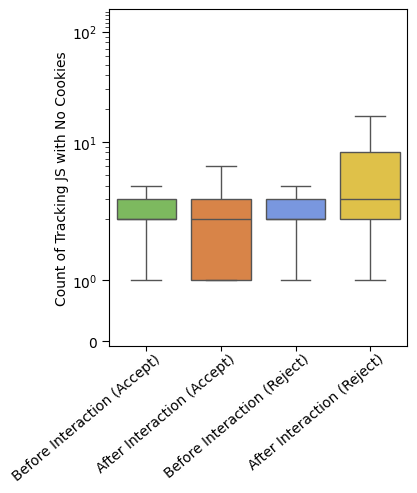

In [7]:
from matplotlib.ticker import NullFormatter, FixedLocator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib as mpl

# ─────────────────────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────────────────────
df_javascript_all = pd.read_csv('js_combined.csv')
df_cookie_all = pd.read_csv('javascript_cookies_combined.csv')


class_map = {
    1: class_1,
    2: class_2,
    3: class_3,
    4: class_4,
    5: class_5,
    6: class_6,
    7: class_7,
    8: class_8,
}

common_domains = set().union(*class_map.values())

modes = [
    "Before Interaction (Accept)",
    "After Interaction (Accept)",
    "Before Interaction (Reject)",
    "After Interaction (Reject)"
]

# ─────────────────────────────────────────────────────────────
# Helper
# ─────────────────────────────────────────────────────────────
def get_stage_counts(df):

    df = df[['visit_id', "clicked_stage", "domain"]]

    grouped = (
        df.groupby(['domain', 'clicked_stage'])
        .size()
        .reset_index(name='count')
    )

    result = pd.merge(
        df[['visit_id', 'domain', 'clicked_stage']],
        grouped,
        on=['domain', 'clicked_stage'],
        how='left'
    )

    result = result.drop_duplicates()

    result = result[
        ['visit_id', 'domain', 'clicked_stage', 'count']
    ]

    return result

json_data = download_disconnect_list()
# ─────────────────────────────────────────────────────────────

# Collect filtered data for all 4 stages
# ─────────────────────────────────────────────────────────────
final_data = []

for mode in modes:

    if json_data :
        df_javascript_all = apply_disconnect_categories_to_dataframe(df_javascript_all, domain_column='domain_script_url')
    print(f"\nProcessing: {mode}")

    # Stage-specific filtering
    df_js = df_javascript_all[
        df_javascript_all['clicked_stage'] == mode
    ].copy()

    df_cookie = df_cookie_all[
        df_cookie_all['clicked_stage'] == mode
    ].copy()

    # Remove first-party cookies
    df_cookie = df_cookie[
        df_cookie['domain_cookie'] != df_cookie['domain']
    ]

    # Domains with tracking cookies
    domains_with_tracking_cookies = set(df_cookie['domain'])

    # Domains WITHOUT tracking cookies
    domains_without_tracking_cookies = (
        common_domains - domains_with_tracking_cookies
    )

    # Keep invasive/general fingerprinting scripts
    df_js = df_js[
        (df_js['AllList'] == True) &
        (
            (df_js['FingerprintingInvasive'] == True) |
            (df_js['FingerprintingGeneral'] == True)
        ) &
        (df_js['domain_script_url'] != df_js['domain'])
    ]

    # Domains with fingerprinting scripts
    domains_with_fingerprinting_scripts = set(df_js['domain'])

    # Only FS and NO cookies
    domain_with_only_fs = (
        domains_with_fingerprinting_scripts &
        domains_without_tracking_cookies
    )

    # Keep only those rows
    df_js = df_js[
        df_js['domain'].isin(domain_with_only_fs)
    ]

    # Get counts
    counts = get_stage_counts(df_js)

    final_data.append(counts)

# Merge all stages together
final_df = pd.concat(final_data, ignore_index=True)
single_col_width = 3.5
# ─────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────
colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

f, axes = plt.subplots(
    1, 1,
    figsize=(
        single_col_width * 1.1,
        single_col_width * 1.25
    )
)

sns.boxplot(
    x='clicked_stage',
    y='count',
    order=modes,
    data=final_df,
    showfliers=False,
    ax=axes,
    palette=colors
)

# ── Symlog scale ─────────────────────────────────────────────
axes.set_yscale("symlog")
axes.set_ylim(-0.075, 160)

# ── Major ticks ──────────────────────────────────────────────
major_ticks = [0, 1, 10, 100]

axes.set_yticks(major_ticks)

axes.set_yticklabels(
    ['0', '$10^{0}$', '$10^{1}$', '$10^{2}$'],
    fontsize=10
)

# ── Minor dash marks ─────────────────────────────────────────
minor_ticks = [
    2, 3, 4, 5, 6, 7, 8, 9,
    20, 30, 40, 50, 60, 70, 80, 90,
    110, 120, 130, 140, 150
]

axes.yaxis.set_minor_locator(FixedLocator(minor_ticks))
axes.yaxis.set_minor_formatter(NullFormatter())

axes.tick_params(
    axis='y',
    which='major',
    length=5,
    width=0.8,
    left=True
)

axes.tick_params(
    axis='y',
    which='minor',
    length=3,
    width=0.5,
    left=True
)

# ── Labels ───────────────────────────────────────────────────
axes.set_ylabel(
    'Count of Tracking JS with No Cookies',
    labelpad=2
)

axes.set_xlabel('')

# ── X tick formatting ────────────────────────────────────────
xtl = axes.get_xticklabels()

axes.set_xticklabels(
    labels=xtl,
    rotation=40,
    ha="right",
    fontsize=10
)

dx = 12 / 72.
dy = 3 / 72.

offset = mpl.transforms.ScaledTranslation(
    dx,
    dy,
    f.dpi_scale_trans
)

for label in axes.xaxis.get_majorticklabels():
    label.set_transform(
        label.get_transform() + offset
    )
    label.set_fontsize(10)

plt.show()

f.savefig(
    'boxplot_tracking_js_no_cookies.pdf',
    bbox_inches='tight',
    dpi=300
)

In [6]:
def get_stage_counts(df):

    df = df[['visit_id', "clicked_stage", "domain"]]
    
    grouped = df.groupby(['domain', 'clicked_stage']).size().reset_index(name='count')
    print(grouped.head(10))
    # stages = ["Before Interaction", "After Interaction"]
    stages = df["clicked_stage"].unique().tolist()

    stages_df = pd.DataFrame({"clicked_stage": stages})
    print(stages_df)
    stages_df["key"] = 1
    print(stages_df)
    result = pd.merge(
        df[['visit_id', 'domain', 'clicked_stage']],
        grouped,
        on=['domain', 'clicked_stage'],
        how='left'
    )

    # Keep unique rows
    result = result.drop_duplicates()

    # Final column order
    result = result[['visit_id', 'domain', 'clicked_stage', 'count']]

    return result

In [3]:
df1 = pd.read_csv("javascript_cookies_combined.csv")

In [ ]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    data = get_stage_counts(df)

    # Print summary statistics
    print("\n===== Statistical Summary for Each Stage =====JS (main)\n")
    print(data.groupby("clicked_stage")["count"].describe())
    print("\n==============================================\n")

    custom_order = [
        "Before Interaction (Accept)",
        "After Interaction (Accept)",
        "Before Interaction (Reject)",
        "After Interaction (Reject)"
    ]

    colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

    # Create figure
    f, axes = plt.subplots(
        1, 1,
        figsize=(
            single_col_width * 0.95,
            single_col_width * 1.2
        )
    )
    # ── Axis border (spines) thickness ─────────────────────
    for spine in axes.spines.values():
        spine.set_linewidth(2)   # try 1.0–2.5 depending on how bold you want
    
    boxplot = sns.boxplot(
        x='clicked_stage',
        y='count',
        order=custom_order,
        data=data,
        showfliers=False,
        ax=axes,
        palette=colors
    )

    # ── Compute medians for each stage ──
    medians = []
    for i, stage in enumerate(custom_order):
        stage_data = data[data['clicked_stage'] == stage]['count']
        median_val = stage_data.median()
        medians.append(median_val)
        
        # Draw dashed horizontal line at median (only within the box area)
        # Get the x-position for this box (0, 1, 2, 3)
        x_pos = i
        # Draw dashed line spanning from left to right of the box
        axes.hlines(
            y=median_val,
            xmin=x_pos - 0.35,  # Adjust based on box width
            xmax=x_pos + 0.35,
            colors='gray',
            linestyle='--',
            linewidth=1.5,
            alpha=0.7,
            zorder=3
        )
        
        # Write median value inside box plot above the median line
        axes.text(
            x_pos,
            median_val,
            f'{median_val:.1f}',
            ha='center',
            va='bottom',
            fontsize=9,
            fontweight='bold',
            color='black',
            zorder=4
        )

    # Get highest value from plotted box elements
    max_range = max(
        line.get_ydata().max()
        for line in boxplot.get_lines()
        if line.get_ydata().size > 0
    )

    # Set symlog scale
    axes.set_yscale("symlog")
    
    # ── Y-axis label: make bold and bring it closer ──────────────────────────────
    axes.set_ylabel(
        f'Count of Tracking {FIG_NAME}',
        fontweight='bold',
        labelpad=2
    )

    # ── Y-axis ticks: 1, 10, 100 in 10^ format and bold ──────────────────
    major_ticks = [1, 10, 100]  # Remove 0 because symlog doesn't show 0 well
    axes.set_yticks(major_ticks)
    axes.set_yticklabels([r'$10^{%d}$' % int(np.log10(tick)) for tick in major_ticks])
    
    # Make y-tick labels bold
    for label in axes.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(10)

    # Minor ticks: fill in 2–9 between each decade
    from matplotlib.ticker import LogLocator, NullFormatter
    axes.yaxis.set_minor_locator(MinorSymLogLocator(1e-1))
    axes.yaxis.set_minor_formatter(NullFormatter())   # no labels on minors

    axes.tick_params(axis='y', which='major', length=5, width=0.8)
    axes.tick_params(axis='y', which='minor', length=3, width=0.5)

    # Add padding above maximum value
    ymax = np.ceil(max_range * 1.2)
    
    # Ensure ymax is at least 100 to show all ticks
    ymax = max(ymax, 100)

    # Apply limits
    axes.set_ylim(0.5, ymax)  # Start from 0.5 to show 10^0 properly

    # Labels
    plt.title('')
    axes.set_xlabel('')

    # X tick formatting - MAKE BOLD
    xtl = axes.get_xticklabels()
    axes.set_xticklabels(
        labels=custom_order,
        rotation=40,
        ha="right",
        fontsize=12,
        fontweight='bold'  # Make x labels bold
    )

    dx = 12 / 72.
    dy = 3 / 72.

    offset = mpl.transforms.ScaledTranslation(
        dx,
        dy,
        f.dpi_scale_trans
    )

    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(
            label.get_transform() + offset
        )
        label.set_fontsize(10)
        label.set_fontweight('bold')  # Ensure bold

    plt.show()

    f.savefig(
        f'boxplot_js_{FIG_NAME}.pdf',
        bbox_inches='tight',
        dpi=300
    )

In [ ]:
# df1 = pd.read_csv("javascript_cookies_combined.csv")
df2 = pd.read_csv("js_combined.csv")

           domain                clicked_stage  count
0  000webhost.com   After Interaction (Accept)      4
1       01net.com   After Interaction (Accept)    414
2       01net.com   After Interaction (Reject)     10
3       01net.com  Before Interaction (Accept)      2
4       01net.com  Before Interaction (Reject)      2
5          021.rs   After Interaction (Accept)    208
6          021.rs   After Interaction (Reject)     30
7          021.rs  Before Interaction (Accept)      2
8          021.rs  Before Interaction (Reject)      2
9     0221.com.ar   After Interaction (Accept)    596
                 clicked_stage
0   After Interaction (Accept)
1  Before Interaction (Accept)
2  Before Interaction (Reject)
3   After Interaction (Reject)
                 clicked_stage  key
0   After Interaction (Accept)    1
1  Before Interaction (Accept)    1
2  Before Interaction (Reject)    1
3   After Interaction (Reject)    1

===== Statistical Summary for Each Stage =====JS (main)

             

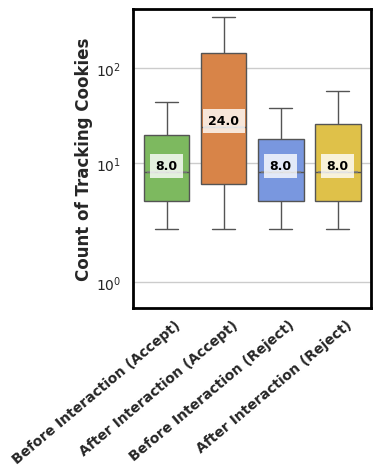

In [48]:
boxplot_tracking_stages(df1, FIG_NAME="Cookies")

           domain                clicked_stage  count
0  000webhost.com   After Interaction (Accept)     14
1  000webhost.com   After Interaction (Reject)     12
2  000webhost.com  Before Interaction (Accept)     17
3  000webhost.com  Before Interaction (Reject)     16
4       01net.com   After Interaction (Accept)    101
5       01net.com   After Interaction (Reject)     35
6       01net.com  Before Interaction (Accept)     15
7       01net.com  Before Interaction (Reject)     15
8          021.rs   After Interaction (Accept)     88
9          021.rs   After Interaction (Reject)     49
                 clicked_stage
0  Before Interaction (Accept)
1   After Interaction (Accept)
2  Before Interaction (Reject)
3   After Interaction (Reject)
                 clicked_stage  key
0  Before Interaction (Accept)    1
1   After Interaction (Accept)    1
2  Before Interaction (Reject)    1
3   After Interaction (Reject)    1

===== Statistical Summary for Each Stage =====JS (main)

             

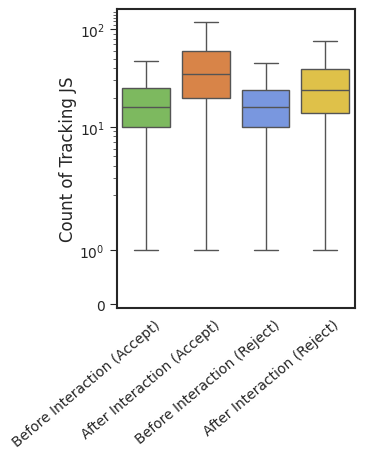

In [63]:
boxplot_tracking_stages(df2, FIG_NAME="JS")

In [46]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    data = get_stage_counts(df)

    # 👉 Print summary stats for each clicked_stage
    print("\n===== Statistical Summary for Each Stage =====JS (main)\n")
    print(data.groupby("clicked_stage")["count"].describe())
    print("\n==============================================\n")

    custom_order = [
        "Before Interaction (Accept)",
        "After Interaction (Accept)",
        "Before Interaction (Reject)",
        "After Interaction (Reject)"
    ]

    colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

    # Create the real figure
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95,
                                          single_col_width * 1.2))

    boxplot = sns.boxplot(
        x='clicked_stage',
        y='count',
        order=custom_order,
        data=data,
        showfliers=False,
        ax=axes,
        palette=colors
    )

    maxl = data["count"].max()

    max_range = max([
        line.get_ydata().max()
        for line in boxplot.get_lines()
        if line.get_ydata().size > 0
    ])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y', which='both', left=True)

    plt.ylim(-0.075, max_range*2+1)

    xtl = axes.get_xticklabels()
    plt.title('')
    # plt.xlabel('Stage')
    # plt.xlabel('Stage')
    axes.set_xlabel('')   # <-- add this line
    plt.ylabel(f'Count of Tracking {FIG_NAME}')

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)

    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)

    plt.show()

    f.savefig(f'boxplot_js_{FIG_NAME}.pdf',
              bbox_inches='tight', dpi=300)


In [71]:
df[['visit_id', "clicked", "domain", 'stage']]

,visit_id,clicked,domain,stage


In [72]:
get_stage_counts(df)

before size 0
after size 0
Empty DataFrame
Columns: [domain, clicked_stage, count]
Index: []
Empty DataFrame
Columns: [clicked_stage]
Index: []
Empty DataFrame
Columns: [clicked_stage, key]
Index: []


,visit_id,domain,clicked_stage,count


In [14]:
plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.autolayout"] = False   # True can cause PDF layout bugs
plt.rcParams["text.usetex"] = False         # Disable LaTeX text
plt.rcParams['figure.figsize'] = (3.35, 7.03)

sns.set_style("white")

single_col_width = 3.6 * 0.9
double_col_width = 7.8 * 0.9


In [65]:
FIG_DIR = './files/figs'
import os
os.makedirs(FIG_DIR, exist_ok=True)


In [ ]:
# Get the stage counts dataframe
stage_counts_df = get_stage_counts(df)
stage_counts_df.to_csv("Raw_javascript_cookies_Accept_3732_5000.csv", index=False)


before size 0
after size 0
Empty DataFrame
Columns: [domain, clicked_stage, count]
Index: []
Empty DataFrame
Columns: [clicked_stage]
Index: []
Empty DataFrame
Columns: [clicked_stage, key]
Index: []


ValueError: max() iterable argument is empty

<Figure size 800x600 with 0 Axes>

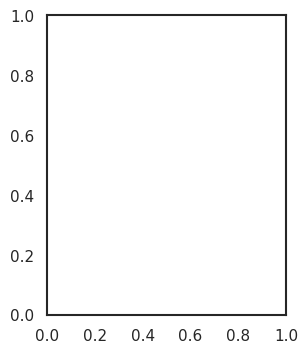

In [73]:
boxplot_tracking_stages(df, FIG_NAME="Cookies (main)")

In [69]:
df = main_map_unique["javascript"]


In [71]:
df = df[df.AllList.astype(bool)]

In [73]:
df['symbol']

0              Navigator.userAgent
6                     Date.getTime
7                     Date.getTime
16             Navigator.userAgent
20             Navigator.userAgent
21    Performance.getEntriesByName
27                 Event.timeStamp
Name: symbol, dtype: str

In [67]:
get_stage_counts(df)



before size 7
after size 7
    domain                clicked_stage  count
0  last.fm  Before Interaction (Reject)      7
                 clicked_stage
0  Before Interaction (Reject)
                 clicked_stage  key
0  Before Interaction (Reject)    1


,visit_id,domain,clicked_stage,count
0,111570286449602,last.fm,Before Interaction (Reject),7


before size 7
after size 7
    domain                clicked_stage  count
0  last.fm  Before Interaction (Reject)      7
                 clicked_stage
0  Before Interaction (Reject)
                 clicked_stage  key
0  Before Interaction (Reject)    1


<Figure size 800x600 with 0 Axes>

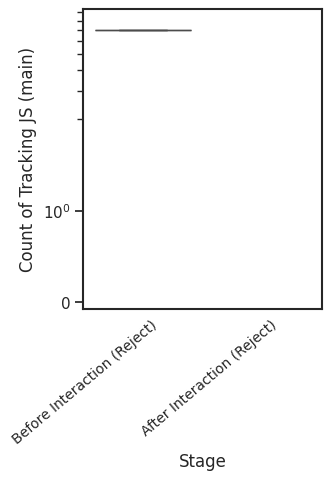

In [74]:
boxplot_tracking_stages(df, FIG_NAME="JS (main)")

In [77]:
def boxplot_tracking_stages_with_zero_cookies(df, FIG_NAME="stages_js"):
    # df = df[df.AllList]
    # visits_df = visits
    # grouped = df.groupby(['visit_id', 'stage']).size().reset_index(name='count')
    # grouped_merged = pd.merge(visits_df['visit_id'], grouped, on='visit_id', how='left').fillna(0)
    data = get_stage_counts(df)
    custom_order =  ["Before Interaction (Reject)", "After Interaction (Reject)"]
    # if data.clicked_stage.nunique()>3:
        # custom_order.extend(["Before Interaction (Accept)", "After Interaction (Accept)", "After Reload (Accept)"])

    # Plotting with Seaborn, applying log scale for the y-axis and ordering the x-axis categories
    plt.figure(figsize=(8, 6))
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95, single_col_width * 1.2))
    boxplot = sns.boxplot(x='clicked_stage', y='count', order=custom_order, data=data, showfliers=False, ax=axes)

    maxl = data["count"].max()
    # axes1.set(xlim=(-0.05, maxl*1.1))

    max_range = max([line.get_ydata().max() for line in boxplot.get_lines() if line.get_ydata().size > 0])
    # min_range = min([line.get_ydata().min() for line in boxplot.get_lines() if line.get_ydata().size > 0])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y',which='both',left=True)
    # Set y-axis limits
    plt.ylim(-0.075, max_range*1.2+1)
        # plt.ylim(0, maxl*1.1)  # Setting y-axis limit from 0 to 100
    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')
    # axes.set(yscale="symlog")
    # axes.set(ylim=(-0.075, 10**3 + 1))

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)
    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)  # Set the desired font size


    plt.show()
    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf', bbox_inches='tight', dpi=300)

In [78]:
df_main = main_map_unique["javascript_cookies"]
df = df_main[df_main.clicked=="reject"]
df = df[df.is_tracking]
domains_with_cookies = df.domain.unique().tolist()

In [80]:
domains_without_cookies = set(df_main.domain.unique().tolist()) - set(domains_with_cookies)

In [81]:
df = main_map_unique["javascript"]
df = df[df.AllList & df.domain.isin(domains_without_cookies)]

In [82]:
vis = visits_main[visits_main.domain.isin(domains_without_cookies)]

In [83]:
# Get the stage counts dataframe
get_stage_counts(df)


before size 7
after size 7
    domain                clicked_stage  count
0  last.fm  Before Interaction (Reject)      7
                 clicked_stage
0  Before Interaction (Reject)
                 clicked_stage  key
0  Before Interaction (Reject)    1


,visit_id,domain,clicked_stage,count
0,111570286449602,last.fm,Before Interaction (Reject),7


before size 7
after size 7
    domain                clicked_stage  count
0  last.fm  Before Interaction (Reject)      7
                 clicked_stage
0  Before Interaction (Reject)
                 clicked_stage  key
0  Before Interaction (Reject)    1


<Figure size 800x600 with 0 Axes>

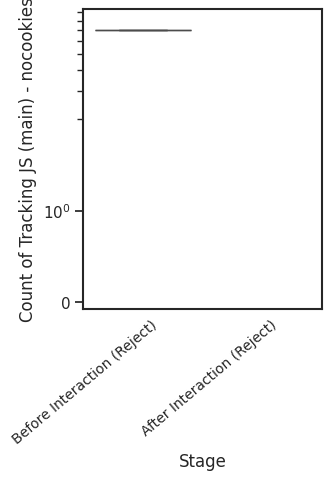

FileNotFoundError: [Errno 2] No such file or directory: './files/figs/boxplot_js_JS (main) - nocookies.pdf'

In [84]:
boxplot_tracking_stages_with_zero_cookies(df, FIG_NAME="JS (main) - nocookies")

In [ ]:
ab = pd.read_csv("/home/ishan/banners_text/javascript_cookies_Reject.csv")

In [ ]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    # df = df[df.AllList]
    # visits_df = visits
    # grouped = df.groupby(['visit_id', 'stage']).size().reset_index(name='count')
    # grouped_merged = pd.merge(visits_df['visit_id'], grouped, on='visit_id', how='left').fillna(0)
    data = df
    custom_order =  ["Before Interaction (Reject)", "After Interaction (Reject)"]
    # if data.clicked_stage.nunique()>3:
        # custom_order.extend(["Before Interaction (Accept)", "After Interaction (Accept)", "After Reload (Accept)"])

    # Plotting with Seaborn, applying log scale for the y-axis and ordering the x-axis categories
    plt.figure(figsize=(8, 6))
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95, single_col_width * 1.2))
    boxplot = sns.boxplot(x='clicked_stage', y='count', order=custom_order, data=data, showfliers=False, ax=axes)

    maxl = data["count"].max()
    # axes1.set(xlim=(-0.05, maxl*1.1))

    max_range = max([line.get_ydata().max() for line in boxplot.get_lines() if line.get_ydata().size > 0])
    # min_range = min([line.get_ydata().min() for line in boxplot.get_lines() if line.get_ydata().size > 0])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y',which='both',left=True)
    # Set y-axis limits
    plt.ylim(-0.075, max_range*1.2+1)
        # plt.ylim(0, maxl*1.1)  # Setting y-axis limit from 0 to 100
    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')
    # axes.set(yscale="symlog")
    # axes.set(ylim=(-0.075, 10**3 + 1))

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)
    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)  # Set the desired font size


    plt.show()
    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf', bbox_inches='tight', dpi=300)

In [ ]:
boxplot_tracking_stages(ab, FIG_NAME="Cookies (main)")

In [ ]:
def boxplot_tracking_stages_with_zero_cookies(df, FIG_NAME="stages_js"):
    # df = df[df.AllList]
    # visits_df = visits
    # grouped = df.groupby(['visit_id', 'stage']).size().reset_index(name='count')
    # grouped_merged = pd.merge(visits_df['visit_id'], grouped, on='visit_id', how='left').fillna(0)
    data = df
    custom_order =  ["Before Interaction (Reject)", "After Interaction (Reject)"]
    # if data.clicked_stage.nunique()>3:
        # custom_order.extend(["Before Interaction (Accept)", "After Interaction (Accept)", "After Reload (Accept)"])

    # Plotting with Seaborn, applying log scale for the y-axis and ordering the x-axis categories
    plt.figure(figsize=(8, 6))
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95, single_col_width * 1.2))
    boxplot = sns.boxplot(x='clicked_stage', y='count', order=custom_order, data=data, showfliers=False, ax=axes)

    maxl = data["count"].max()
    # axes1.set(xlim=(-0.05, maxl*1.1))

    max_range = max([line.get_ydata().max() for line in boxplot.get_lines() if line.get_ydata().size > 0])
    # min_range = min([line.get_ydata().min() for line in boxplot.get_lines() if line.get_ydata().size > 0])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y',which='both',left=True)
    # Set y-axis limits
    plt.ylim(-0.075, max_range*1.2+1)
        # plt.ylim(0, maxl*1.1)  # Setting y-axis limit from 0 to 100
    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')
    # axes.set(yscale="symlog")
    # axes.set(ylim=(-0.075, 10**3 + 1))

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)
    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)  # Set the desired font size


    plt.show()
    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf', bbox_inches='tight', dpi=300)

In [ ]:
cd = pd.read_csv("/home/ishan/banners_text/javascript_no_cookies_Reject.csv")

In [ ]:
boxplot_tracking_stages_with_zero_cookies(cd, FIG_NAME="JS (main) - nocookies")

In [ ]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    # df = df[df.AllList]
    # visits_df = visits
    # grouped = df.groupby(['visit_id', 'stage']).size().reset_index(name='count')
    # grouped_merged = pd.merge(visits_df['visit_id'], grouped, on='visit_id', how='left').fillna(0)
    data = df
    custom_order =  ["Before Interaction (Reject)", "After Interaction (Reject)"]
    # if data.clicked_stage.nunique()>3:
        # custom_order.extend(["Before Interaction (Accept)", "After Interaction (Accept)", "After Reload (Accept)"])

    # Plotting with Seaborn, applying log scale for the y-axis and ordering the x-axis categories
    plt.figure(figsize=(8, 6))
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95, single_col_width * 1.2))
    boxplot = sns.boxplot(x='clicked_stage', y='count', order=custom_order, data=data, showfliers=False, ax=axes)

    maxl = data["count"].max()
    # axes1.set(xlim=(-0.05, maxl*1.1))

    max_range = max([line.get_ydata().max() for line in boxplot.get_lines() if line.get_ydata().size > 0])
    # min_range = min([line.get_ydata().min() for line in boxplot.get_lines() if line.get_ydata().size > 0])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y',which='both',left=True)
    # Set y-axis limits
    plt.ylim(-0.075, max_range*1.2+1)
        # plt.ylim(0, maxl*1.1)  # Setting y-axis limit from 0 to 100
    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')
    # axes.set(yscale="symlog")
    # axes.set(ylim=(-0.075, 10**3 + 1))

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)
    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)  # Set the desired font size


    plt.show()
    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf', bbox_inches='tight', dpi=300)

In [ ]:
ef = pd.read_csv("/home/ishan/banners_text/javascript_Reject.csv")

In [ ]:
boxplot_tracking_stages(ef, FIG_NAME="JS (main)")

In [ ]:


plt.rcParams['font.size'] = 9
plt.rcParams['axes.linewidth'] = 2
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["savefig.dpi"] = 3000
plt.rcParams["figure.autolayout"] = True
plt.rcParams["text.usetex"] = True
plt.rcParams['figure.figsize'] = 3.35,7.03
single_col_width = 3.6 * 0.9
double_col_width = 7.8 * 0.9
sns.set_style("white")


In [41]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    # df = df[df.AllList]
    # visits_df = visits
    # grouped = df.groupby(['visit_id', 'stage']).size().reset_index(name='count')
    # grouped_merged = pd.merge(visits_df['visit_id'], grouped, on='visit_id', how='left').fillna(0)
    data = df
    custom_order =  ["Before Interaction (Reject)", "After Interaction (Reject)","Before Interaction (Accept)", "After Interaction (Accept)"]


    # Plotting with Seaborn, applying log scale for the y-axis and ordering the x-axis categories
    plt.figure(figsize=(8, 6))
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95, single_col_width * 1.2))
    boxplot = sns.boxplot(x='clicked_stage', y='count', order=custom_order, data=data, showfliers=False, ax=axes)

    maxl = data["count"].max()
    # axes1.set(xlim=(-0.05, maxl*1.1))

    max_range = max([line.get_ydata().max() for line in boxplot.get_lines() if line.get_ydata().size > 0])
    # min_range = min([line.get_ydata().min() for line in boxplot.get_lines() if line.get_ydata().size > 0])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y',which='both',left=True)
    # Set y-axis limits
    plt.ylim(-0.075, max_range*1.2+1)
        # plt.ylim(0, maxl*1.1)  # Setting y-axis limit from 0 to 100
    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')
    # axes.set(yscale="symlog")
    # axes.set(ylim=(-0.075, 10**3 + 1))

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)
    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)  # Set the desired font size


    plt.show()
    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf', bbox_inches='tight', dpi=300)

In [ ]:
def boxplot_tracking_stages(df, FIG_NAME="stages_js"):
    data = get_stage_count(df)

    # 👉 Print summary stats for each clicked_stage
    print("\n===== Statistical Summary for Each Stage =====JS (main)\n")
    print(data.groupby("clicked_stage")["count"].describe())
    print("\n==============================================\n")

    custom_order = [
        "Before Interaction (Accept)",
        "After Interaction (Accept)",
        "Before Interaction (Reject)",
        "After Interaction (Reject)"
    ]

    colors = ['#78C850', '#F08030', '#6890F0', '#F8D030']

    # Create the real figure
    f, axes = plt.subplots(1, 1, figsize=(single_col_width * 0.95,
                                          single_col_width * 1.2))

    boxplot = sns.boxplot(
        x='clicked_stage',
        y='count',
        order=custom_order,
        data=data,
        showfliers=False,
        ax=axes,
        palette=colors
    )

    maxl = data["count"].max()

    max_range = max([
        line.get_ydata().max()
        for line in boxplot.get_lines()
        if line.get_ydata().size > 0
    ])

    axes.set(yscale="symlog")
    yaxis = boxplot.yaxis
    yaxis.set_minor_locator(MinorSymLogLocator(1e-1))

    axes.tick_params(axis='y', which='both', left=True)

    plt.ylim(-0.075, max_range*1.2+1)

    xtl = axes.get_xticklabels()
    plt.title('')
    plt.xlabel('Stage')
    plt.ylabel(f'Count of Tracking {FIG_NAME}')

    axes.set_xticklabels(labels=xtl, rotation=40, ha="right", fontsize=12)

    dx = 12 / 72.
    dy = 3 / 72.
    offset = mpl.transforms.ScaledTranslation(dx, dy, f.dpi_scale_trans)

    for label in axes.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + offset)
        label.set_fontsize(10)

    plt.show()

    f.savefig(FIG_DIR + f'/boxplot_js_{FIG_NAME}.pdf',
              bbox_inches='tight', dpi=300)


In [ ]:
ab = pd.read_csv("/home/ishan/banners_text/javascript_cookies_combined.csv")

In [ ]:
boxplot_tracking_stages(ab, FIG_NAME="JS (main)")

In [ ]:
df_2 = main_map_unique["javascript"]
df_2 = df_2[df_2["clicked"].notna()]
df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)


In [ ]:
with open('/home/ishan/banners_text/transparent_domains.csv', 'r') as file:
    transparent_disclosure = [line.strip() for line in file.readlines()]
with open('/home/ishan/banners_text/partially_ambiguous_domains.csv', 'r') as file:
    partially_ambiguous = [line.strip() for line in file.readlines()]

with open('/home/ishan/banners_text/completely_ambiguious_domains.csv', 'r') as file:
    complete_ambiguous = [line.strip() for line in file.readlines()]

with open('/home/ishan/banners_text/empty_no_disclosure_domains.csv', 'r') as file:
    no_disclosure = [line.strip() for line in file.readlines()]


with open('/home/ishan/unique_domains_can_analyze_banner.csv', 'r') as file:
    unique_domains_can_analyze_banner = [line.strip() for line in file.readlines()]

class_1, class_2, class_3, class_4 = [], [], [], []
class_5, class_6, class_7, class_8 = [], [], [], []

base_path = "/home/ishan/banners_text/class_"

for i in range(1, 8+1):
    file_path = f"{base_path}{i}.csv"

    try:
        with open(file_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception:
        lines = []   # File missing or empty -> ignore safely

    globals()[f"class_{i}"] = lines



In [ ]:
print(class_1[:5])   # first 5 domains from class_1.csv
print(class_8[:5])

## Cookies

In [ ]:
df_1 = main_map_unique["javascript_cookies"]
df_1 = df_1[df_1["clicked"].notna()]
df_1["clicked_stage"] = df_1["stage"] + " (" + df_1["clicked"].str.capitalize() + ")"
df_1['domain_cookie'] = df_1['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)


In [ ]:
print(df.shape)

In [ ]:
print((df_1['clicked_stage'] == "After Interaction (Accept)").sum())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
import gc
import os

# Define colors for the groups
colors = plt.cm.tab20.colors
common_domains = set(unique_domains_can_analyze_banner)



def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""

    if domain in class_1:
        return 1
    if domain in class_2:
        return 2
    if domain in class_3:
        return 3
    if domain in class_4:
        return 4
    if domain in class_5:
        return 5
    if domain in class_6:
        return 6
    if domain in class_7:
        return 7
    if domain in class_8:
        return 8
    return None


def process_single_file(df_):
    """Process a single cookie file and return unique cookies"""
    print(f"\nProcessing: {file_path}")

    # Load one file
    df_cookie = df_
    print(f"  Loaded {len(df_cookie)} rows")

    df_cookie_accept = df_cookie[df_cookie['clicked_stage'].isin([
        'After Interaction (Accept)',
    ])]
    # print(df_cookie_accept)
    # print('check')
    # print(df_cookie_accept[df_cookie_accept['domain'].isin(common_domains)])
    df_cookie_accept = df_cookie_accept[
        (df_cookie_accept['domain_cookie'] != df_cookie_accept['domain']) 
    ]
    # print("modified")
    # print(df_cookie_accept)
    # print(f"  After filtering: {len(df_cookie_accept)} rows")

    # Assign disclosure group
    df_cookie_accept['disclosure_group'] = df_cookie_accept['domain'].apply(assign_disclosure_group)
    df_cookie_accept = df_cookie_accept[df_cookie_accept['disclosure_group'].notnull()]

    print(f"  After disclosure assignment: {len(df_cookie_accept)} rows")

    # Extract unique cookies from this file
    cookies_this_file = df_cookie_accept[
        ['disclosure_group', 'domain', 'host_url', 'name']
    ].drop_duplicates()

    print(f"  Unique cookies in this file: {len(cookies_this_file)}")



    return cookies_this_file



# ============================================================
# MAIN PROCESSING LOOP
# ============================================================
print("="*60)
print("INCREMENTAL COOKIE DATA PROCESSING")
print("="*60)


# Process this file
cookies_from_file = process_single_file(df_1)






## GRaph Cookies

In [ ]:
INTERMEDIATE_FILE = "accumulated_cookies_new.parquet"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# ========== CONFIGURATION ==========
# TODO: Define your class domain lists
# class_1 = set()  # Add your domains here
# class_2 = set()
# class_3 = set()
# class_4 = set()
# class_5 = set()
# class_6 = set()
# class_7 = set()
# class_8 = set()

# TODO: Define your parquet file path
# INTERMEDIATE_FILE = "cookies_data.parquet"

# Colors for visualization
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
# ===================================

def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""
    if domain in class_1: return 1
    if domain in class_2: return 2
    if domain in class_3: return 3
    if domain in class_4: return 4
    if domain in class_5: return 5
    if domain in class_6: return 6
    if domain in class_7: return 7
    if domain in class_8: return 8
    return None

# Create class to domain mapping
class_map = {
    1: class_1,
    2: class_2,
    3: class_3,
    4: class_4,
    5: class_5,
    6: class_6,
    7: class_7,
    8: class_8,
}

# Get all common domains across all classes
common_domains = set().union(*class_map.values())

# ============================================================
# FINAL ANALYSIS (CLASS-BASED GROUPS)
# ============================================================
print("\nLoading final accumulated data for analysis...")
all_cookies_unique = pd.read_parquet(INTERMEDIATE_FILE)
print(f"Total unique cookies across all files: {len(all_cookies_unique)}")

# Assign disclosure group based on class lists
all_cookies_unique['disclosure_group'] = all_cookies_unique['domain'].apply(assign_disclosure_group)

# Map class numbers to readable names
class_mapping = {
    1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
    5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8",
    None: "Unassigned"
}
all_cookies_unique['disclosure_group'] = all_cookies_unique['disclosure_group'].map(class_mapping)

# Count cookies per domain
cookie_counts = all_cookies_unique.groupby(
    ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')

combined_data = cookie_counts.groupby(
    ['disclosure_group', 'domain']
)['cookie_count'].sum().reset_index(name='total_cookie_count')

print(f"Domains with cookies: {len(combined_data)}")

# Save intermediate result
combined_data.to_csv("cookie_analysis_classes.csv", index=False)

# Add missing domains with cookie_count = 0 for each class
def create_zero_entries(domain_list, class_num):
    missing_domains = list(
        set(domain_list) - set(combined_data[combined_data['disclosure_group'] == f"Class {class_num}"]['domain'])
    )
    return pd.DataFrame({
        'disclosure_group': [f"Class {class_num}"] * len(missing_domains),
        'domain': missing_domains,
        'total_cookie_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(class_1, 1),
    create_zero_entries(class_2, 2),
    create_zero_entries(class_3, 3),
    create_zero_entries(class_4, 4),
    create_zero_entries(class_5, 5),
    create_zero_entries(class_6, 6),
    create_zero_entries(class_7, 7),
], ignore_index=True)

print(f"\nTotal zero entries: {len(zero_entries)}")

# Print zero entries statistics
group_counts = zero_entries['disclosure_group'].value_counts()
print("\nNumber of zero entries per class:")
for group, count in group_counts.items():
    print(f"  - {group}: {count}")

combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)
combined_data_cookies = combined_data.copy()

# Compute descriptive statistics
stats = combined_data.groupby("disclosure_group")["total_cookie_count"].describe()
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nDescriptive Statistics:")
print(stats)

# ============================================================
# EXTRA ANALYSIS — COMBINED MEDIANS FOR BROAD GROUPS
# ============================================================

print("\nCombined Median Analysis (Broad Groups):")

# Transparent: Classes 1, 2, 3
transparent_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 1", "Class 2", "Class 3"])
]['total_cookie_count'].median()

# Partially Ambiguous: Classes 4, 5, 6
partially_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6"])
]['total_cookie_count'].median()

# Completely Ambiguous: Class 7
complete_median = combined_data[
    combined_data['disclosure_group'] == "Class 7"
]['total_cookie_count'].median()

# Ambiguous overall: 4,5,6,7
ambiguous_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6", "Class 7"])
]['total_cookie_count'].median()

print(f" → Transparent (1,2,3): Median = {transparent_median}")
print(f" → Partially Ambiguous (4,5,6): Median = {partially_median}")
print(f" → Completely Ambiguous (7): Median = {complete_median}")
print(f" → Ambiguous All (4,5,6,7): Median = {ambiguous_median}")
print("============================================================\n")

# Print sorted values for each class
for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[
        combined_data['disclosure_group'] == group
    ]['total_cookie_count'].sort_values()
    print(f"\n{group} total_cookie_count values:\n{group_values.values}\n")

# ============================================================
# VISUALIZATION - CLASSES 1-7
# ============================================================
plot_data = combined_data[
    ~combined_data['disclosure_group'].isin(["Class 3", "Class 8"])
]
fig, axes = plt.subplots(1, 1, figsize=(6, 8))

order = ["Class 1", "Class 2", "Class 4", "Class 5", "Class 6", "Class 7"]

bp = sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=plot_data,
    order=order,
    palette=colors[:6],
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v",
    legend=False
)

# Customize the plot
axes.set_ylabel("cookies", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=20)
axes.set_yscale("symlog")
axes.set_ylim(0, 10**3)

# Modify x-tick labels (Class 1 -> C1, etc.)
xtick_labels = [label.get_text().replace("Class ", "C") for label in axes.get_xticklabels()]
axes.set_xticklabels(
    xtick_labels,
    rotation=0,
    fontsize=20,
    fontweight='bold',
    ha='center'
)

# ===== FINAL X-LABEL OVERRIDE (AFTER ALL COMPUTATION) =====
ax = axes   # important: reuse the same axis, NOT plt.gca()

old_labels = [l.get_text() for l in ax.get_xticklabels()]
print("Old order:", old_labels)

new_labels = [
    "C",
    "F",
    "V,C",
    "V,F",
    "V,C,F",
    "V"
]

assert len(old_labels) == len(new_labels), "Label count mismatch!"

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    new_labels,
    fontsize=20,
    fontweight="bold"
)

# Shift labels right (optional)
plt.setp(
    axes.get_xticklabels(),
    x=0.12,
    rotation_mode='anchor'
)

for tick in axes.get_xticklabels():
    x, y = tick.get_position()
    tick.set_position((x + 0.05, y))

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("cookie_class_groups.pdf")
plt.show()

print("\n" + "="*60)
print("✓ PROCESSING COMPLETE!")
print("="*60)
print(f"→ Plot saved as 'cookie_class_groups.pdf'")
print(f"→ Accumulated data saved in '{INTERMEDIATE_FILE}'")
print("="*60)

# ============================================================
# VISUALIZATION — BROAD 3-GROUP VERSION
# ============================================================

# Map class → broader disclosure group
broad_map = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
}

# Apply only for classes 1–7
plot_data_broad = plot_data.copy()
plot_data_broad = plot_data_broad[
    plot_data_broad['disclosure_group'] != 'Class 8'
]

plot_data_broad['broad_group'] = plot_data_broad['disclosure_group'].map(broad_map)

# Boxplot with broad groups
fig, axes = plt.subplots(1, 1, figsize=(5, 7))

order_broad = ["Transparent", "Partially Ambiguous", "Completely Ambiguous"]

bp = sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=plot_data_broad,
    order=order_broad,
    palette=colors[:3],
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v",
    legend=False
)

# Customize the plot
axes.set_ylabel("cookies", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=22)
axes.set_yscale("symlog")
axes.set_ylim(0, 10**3)

# Rotate labels + shift
axes.set_xticklabels(
    order_broad,
    rotation=25,
    fontsize=20,
    fontweight='bold',
    ha='right'
)

# Shift labels
plt.setp(
    axes.get_xticklabels(),
    x=0.12,
    rotation_mode='anchor'
)

for label in axes.get_xticklabels():
    x, y = label.get_position()
    label.set_position((x, y - 0.025))

# Style y-ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))







plt.tight_layout()
plt.savefig("cookie_broad_groups.pdf")
plt.show()

print("\n" + "="*60)
print("✓ BROAD GROUP VISUALIZATION COMPLETE!")
print("="*60)
print(f"→ Plot saved as 'cookie_broad_groups.pdf'")
print("="*60)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd

# ============================================================
# CONFIGURATION
# ============================================================

# TODO: define these
# class_1 = set()
# class_2 = set()
# class_3 = set()
# class_4 = set()
# class_5 = set()
# class_6 = set()
# class_7 = set()
# class_8 = set()
# INTERMEDIATE_FILE = "cookies_data.parquet"

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

# ============================================================
# HELPERS
# ============================================================

def assign_disclosure_group(domain):
    if domain in class_1: return 1
    if domain in class_2: return 2
    if domain in class_3: return 3
    if domain in class_4: return 4
    if domain in class_5: return 5
    if domain in class_6: return 6
    if domain in class_7: return 7
    if domain in class_8: return 8
    return None

# ============================================================
# LOAD DATA
# ============================================================

print("\nLoading data...")
all_cookies_unique = pd.read_parquet(INTERMEDIATE_FILE)
print(f"Total unique cookies: {len(all_cookies_unique)}")

# Assign class
all_cookies_unique['disclosure_group'] = (
    all_cookies_unique['domain']
    .apply(assign_disclosure_group)
    .map({
        1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
        5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8"
    })
)

# ============================================================
# DOMAIN-LEVEL COOKIE COUNTS
# ============================================================

cookie_counts = all_cookies_unique.groupby(
    ['disclosure_group', 'domain', 'host_url', 'name']
).size().reset_index(name='cookie_count')

combined_data = cookie_counts.groupby(
    ['disclosure_group', 'domain']
)['cookie_count'].sum().reset_index(name='total_cookie_count')

# ============================================================
# ZERO PADDING
# ============================================================

def zero_entries(domains, cls):
    missing = set(domains) - set(
        combined_data[combined_data['disclosure_group'] == f"Class {cls}"]['domain']
    )
    return pd.DataFrame({
        'disclosure_group': f"Class {cls}",
        'domain': list(missing),
        'total_cookie_count': 0
    })

combined_data = pd.concat([
    combined_data,
    zero_entries(class_1, 1),
    zero_entries(class_2, 2),
    zero_entries(class_3, 3),
    zero_entries(class_4, 4),
    zero_entries(class_5, 5),
    zero_entries(class_6, 6),
    zero_entries(class_7, 7),
], ignore_index=True)

combined_data.to_csv("cookie_analysis_classes.csv", index=False)

# ============================================================
# CLASS-LEVEL STATISTICS
# ============================================================

stats = combined_data.groupby("disclosure_group")["total_cookie_count"].describe()
stats = stats.rename(columns={
    "mean": "Mean", "50%": "Median",
    "std": "Std Dev", "min": "Min", "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nClass-level Statistics:")
print(stats)

# ============================================================
# BROAD GROUP COLUMN (ONCE)
# ============================================================

broad_map = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
}

combined_data['broad_group'] = combined_data['disclosure_group'].map(broad_map)

# ============================================================
# BROAD-GROUP STATISTICS (MEAN + MEDIAN)
# ============================================================

broad_stats = combined_data.dropna(subset=['broad_group']).groupby(
    "broad_group"
)["total_cookie_count"].describe()

broad_stats = broad_stats.rename(columns={
    "mean": "Mean", "50%": "Median",
    "std": "Std Dev", "min": "Min", "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nBroad-group Statistics:")
print(broad_stats)

broad_stats.to_csv("stats_broad_groups.csv")

# ============================================================
# CLASS-LEVEL PLOT (EXCLUDING C3, C8)
# ============================================================

plot_data = combined_data[
    ~combined_data['disclosure_group'].isin(["Class 3", "Class 8"])
]

order = ["Class 1", "Class 2", "Class 4", "Class 5", "Class 6", "Class 7"]

fig, ax = plt.subplots(figsize=(6, 8))

sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=plot_data,
    order=order,
    palette=colors[:6],
    showfliers=False,
    ax=ax
)

ax.set_yscale("symlog")
ax.set_ylim(0, 10**3)
ax.set_ylabel("cookies", fontsize=26, fontweight="bold")
ax.set_xlabel("")

# ===== FINAL X-LABEL OVERRIDE =====
new_labels = ["C", "F", "V,C", "V,F", "V,C,F", "V"]
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(new_labels, fontsize=20, fontweight="bold")

ax.tick_params(axis='y', labelsize=20)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

plt.tight_layout()
plt.savefig("cookie_class_groups.pdf")
plt.show()

# ============================================================
# BROAD-GROUP PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(5, 7))

sns.boxplot(
    x="broad_group",
    y="total_cookie_count",
    data=combined_data.dropna(subset=['broad_group']),
    order=["Transparent", "Partially Ambiguous", "Completely Ambiguous"],
    palette=colors[:3],
    showfliers=False,
    ax=ax
)

ax.set_yscale("symlog")
ax.set_ylim(0, 10**3)
ax.set_ylabel("cookies", fontsize=26, fontweight="bold")
ax.set_xlabel("")

ax.tick_params(axis='y', labelsize=20)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

plt.tight_layout()
plt.savefig("cookie_broad_groups.pdf")
plt.show()

print("\n✓ ALL PROCESSING COMPLETE")


## JS

In [4]:
import pandas as pd
df_2 = pd.read_csv("REJECT/js.csv")
df_1 = pd.read_csv("REJECT/javascript_cookies.csv")

In [6]:
import requests
import json
import os

def download_disconnect_list():
    """
    Download the Disconnect.me tracker protection list
    """
    # URL for the Disconnect.me services list
    url = "https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json"

    print("Downloading Disconnect.me tracker list...")
    print(f"URL: {url}")

    try:
        # Download the file
        response = requests.get(url, timeout=30)
        response.raise_for_status()  # Raise an error for bad status codes

        # Parse JSON
        json_data = response.json()

        # Create directory if it doesn't exist
        os.makedirs('dataset_disconnect', exist_ok=True)

        # Save to file
        output_file = 'dataset_disconnect/services-relay-disconnect.json'
        with open(output_file, 'w', encoding='utf-8') as f:
            json.dump(json_data, f, indent=2, ensure_ascii=False)

        print(f"✓ Successfully downloaded and saved to: {output_file}")

        # Display available categories
        if 'categories' in json_data:
            print("\nAvailable categories:")
            for category in json_data['categories'].keys():
                domain_count = len(json_data['categories'][category])
                print(f"  - {category}: {domain_count} domains")

        return json_data

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading file: {e}")
        print("\nAlternative URLs to try:")
        print("1. https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json")
        print("2. https://services.disconnect.me/disconnect-plaintext.json")
        return None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None

def extract_domains_from_category(category_list):
    """
    Extract all domains from a nested category structure

    Format:
    [
      {"ServiceName": {"url": ["domain1", "domain2"]}},
      ...
    ]
    """
    domains = set()

    for item in category_list:
        # Each item is a dict with one key (service name)
        for service_name, service_data in item.items():
            # service_data is a dict with URLs as keys and domain lists as values
            for url, domain_list in service_data.items():
                # Add all domains from the list
                domains.update(domain_list)

    return domains

def load_and_process_disconnect_data(json_file='dataset_disconnect/services-relay-disconnect.json'):
    """
    Load the Disconnect.me list and extract fingerprinting domains
    """
    print(f"\nLoading Disconnect.me data from: {json_file}")

    try:
        with open(json_file, 'r', encoding='utf-8') as f:
            json_data = json.load(f)

        # Extract domains from FingerprintingInvasive and FingerprintingGeneral categories
        fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
        fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])

        # Parse the nested structure to extract actual domains
        fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
        fp_general_domains = extract_domains_from_category(fp_general_list)


        print(f"✓ Loaded successfully")
        print(f"  - FingerprintingInvasive domains: {len(fp_invasive_domains)}")
        print(f"  - FingerprintingGeneral domains: {len(fp_general_domains)}")


        # Display some example domains
        if fp_invasive_domains:
            print(f"\nExample FingerprintingInvasive domains:")
            for domain in list(fp_invasive_domains)[:5]:
                print(f"  - {domain}")

        if fp_general_domains:
            print(f"\nExample FingerprintingGeneral domains:")
            for domain in list(fp_general_domains)[:5]:
                print(f"  - {domain}")

        return fp_invasive_domains, fp_general_domains

    except FileNotFoundError:
        print(f"✗ File not found: {json_file}")
        print("Run download_disconnect_list() first to download the file.")
        return None, None, None, None
    except json.JSONDecodeError as e:
        print(f"✗ Error parsing JSON: {e}")
        return None, None, None, None

def apply_disconnect_categories_to_dataframe(df, domain_column='domain_script_url'):
    """
    Apply FingerprintingInvasive and FingerprintingGeneral boolean columns to dataframe

    Parameters:
    - df: pandas DataFrame with script/request data
    - domain_column: column name containing the domain to check
    """
    # Load the disconnect data
    fp_invasive_domains, fp_general_domains = load_and_process_disconnect_data()

    if fp_invasive_domains is None:
        print("Failed to load Disconnect.me data. Attempting to download...")
        json_data = download_disconnect_list()
        if json_data:
            fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
            fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])


            fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
            fp_general_domains = extract_domains_from_category(fp_general_list)

        else:
            return df

    # Create boolean columns
    print(f"\nApplying categories to dataframe...")
    df['FingerprintingInvasive'] = df[domain_column].isin(fp_invasive_domains)
    df['FingerprintingGeneral'] = df[domain_column].isin(fp_general_domains)


    print(f"✓ Categories applied:")
    print(f"  - FingerprintingInvasive: {df['FingerprintingInvasive'].sum()} matches")
    print(f"  - FingerprintingGeneral: {df['FingerprintingGeneral'].sum()} matches")


    return df

# ============================================================
# MAIN EXECUTION
# ============================================================
if __name__ == "__main__":
    print("="*60)
    print("DISCONNECT.ME TRACKER LIST DOWNLOADER")
    print("="*60)
    # df_2 = main_map_unique["javascript"]
    # df_2 = df_2[df_2["clicked"].notna()]
    # df_2["clicked_stage"] = df_2["stage"] + " (" + df_2["clicked"].str.capitalize() + ")"
    # df_2['domain_script_url'] = df_2['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)

    # Step 1: Download the list
    json_data = download_disconnect_list()

    if json_data:
        # Step 2: Load and process
        df_2 = apply_disconnect_categories_to_dataframe(df_2, domain_column='domain_script_url')


DISCONNECT.ME TRACKER LIST DOWNLOADER
URL: https://raw.githubusercontent.com/disconnectme/disconnect-tracking-protection/master/services.json
✓ Successfully downloaded and saved to: dataset_disconnect/services-relay-disconnect.json

Available categories:
  - Email: 83 domains
  - EmailAggressive: 84 domains
  - Advertising: 1272 domains
  - Content: 101 domains
  - Analytics: 355 domains
  - FingerprintingInvasive: 282 domains
  - FingerprintingGeneral: 98 domains
  - Anti-fraud: 15 domains
  - Social: 16 domains
  - ConsentManagers: 7 domains
  - Cryptomining: 14 domains

Loading Disconnect.me data from: dataset_disconnect/services-relay-disconnect.json
✓ Loaded successfully
  - FingerprintingInvasive domains: 377
  - FingerprintingGeneral domains: 179

Example FingerprintingInvasive domains:
  - reichelcormier.bid
  - analytics.webgains.io
  - news.jennydanny.com
  - gonreommon.com
  - wpadmngr.com

Example FingerprintingGeneral domains:
  - cdn-net.com
  - doubleclick.net
  - develo

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np
import pandas as pd
import gc
import os

# Define colors for the groups
colors = plt.cm.tab20.colors
# common_domains = set(unique_domains_can_analyze_banner)



def assign_disclosure_group(domain):
    """Return class number (1–8) for the domain, or None if not found."""

    if domain in class_1:
        return 1
    if domain in class_2:
        return 2
    if domain in class_3:
        return 3
    if domain in class_4:
        return 4
    if domain in class_5:
        return 5
    if domain in class_6:
        return 6
    if domain in class_7:
        return 7
    if domain in class_8:
        return 8

    return None


def process_single_file(df_j):


    # Load one file
    df_javascript = df_j
    print(f"  Loaded {len(df_javascript)} rows")

    # Filter for relevant stages and fingerprinting scripts
    df_javascript_accept = df_javascript[df_javascript['clicked_stage'].isin([
        'After Interaction (Reject)',
    ])]

    df_javascript_accept = df_javascript_accept[
        (df_javascript_accept['AllList'] == True) &
        ((df_javascript_accept['FingerprintingInvasive'] == True) |
         (df_javascript_accept['FingerprintingGeneral'] == True)) &
        (df_javascript_accept['domain_script_url'] != df_javascript_accept['domain']) 

    ]

    print(f"  After filtering: {len(df_javascript_accept)} rows")

    # Assign disclosure group
    df_javascript_accept['disclosure_group'] = df_javascript_accept['domain'].apply(assign_disclosure_group)
    df_javascript_accept = df_javascript_accept[df_javascript_accept['disclosure_group'].notnull()]

    print(f"  After disclosure assignment: {len(df_javascript_accept)} rows")

    # Extract unique scripts from this file
    scripts_this_file = df_javascript_accept[
        ['disclosure_group', 'domain', 'host_url']
    ].drop_duplicates()

    print(f"  Unique scripts in this file: {len(scripts_this_file)}")


    return scripts_this_file

def accumulate_and_save(new_scripts, intermediate_file):
    """
    Load existing accumulated data, merge with new data, deduplicate, and save
    """
    if os.path.exists(intermediate_file):
        # Load existing accumulated data
        print(f"  Loading existing accumulated data from {intermediate_file}")
        existing_scripts = pd.read_parquet(intermediate_file)
        print(f"  Existing unique scripts: {len(existing_scripts)}")

        # Combine with new data
        combined = pd.concat([existing_scripts, new_scripts], ignore_index=True)

    else:
        print(f"  No existing accumulated data, starting fresh")
        combined = new_scripts

    # Deduplicate
    combined_unique = combined.drop_duplicates(
        subset=['disclosure_group', 'domain', 'host_url']
    )
    print(f"  Total unique scripts after merging: {len(combined_unique)}")

    # Save back to disk
    combined_unique.to_parquet(intermediate_file, index=False)
    print(f"  Saved accumulated data to {intermediate_file}")


# ============================================================
# MAIN PROCESSING LOOP
# ============================================================

js_from_file = process_single_file(df_2)

# # Accumulate with existing data and save
# accumulate_and_save(scripts_from_file, INTERMEDIATE_FILE_JS)


  Loaded 1157974 rows
  After filtering: 115860 rows
  After disclosure assignment: 115860 rows
  Unique scripts in this file: 115860


## GRAPH JS

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import LogLocator


Total unique scripts across all files: 115860
Domains with scripts: 11134

Total zero entries: 22339

Number of zero entries per class:
  - Class 2: 13303
  - Class 5: 5586
  - Class 4: 2793
  - Class 1: 296
  - Class 7: 230
  - Class 6: 127
  - Class 3: 4

Descriptive Statistics:
                    count       Mean    Std Dev  Min  Median   Max
disclosure_group                                                  
Class 1             478.0   5.669456  11.219160  0.0     0.0  65.0
Class 2           16774.0   0.920413   3.362557  0.0     0.0  63.0
Class 3               5.0   2.800000   6.260990  0.0     0.0  14.0
Class 4            8468.0  10.096599  11.426851  0.0     7.0  81.0
Class 5            7000.0   1.169571   3.955455  0.0     0.0  59.0
Class 6             350.0   6.600000   7.788390  0.0     3.0  34.0
Class 7             324.0   2.645062   6.446777  0.0     0.0  47.0
Class 8              74.0  11.418919  12.876661  1.0     5.0  48.0

Combined Median Analysis (Broad Groups):
 → Tra

/tmp/ipykernel_3404172/872277097.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/tmp/ipykernel_3404172/872277097.py:145: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(
/tmp/ipykernel_3404172/872277097.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(


Old order: ['C1', 'C2', 'C4', 'C5', 'C6', 'C7']


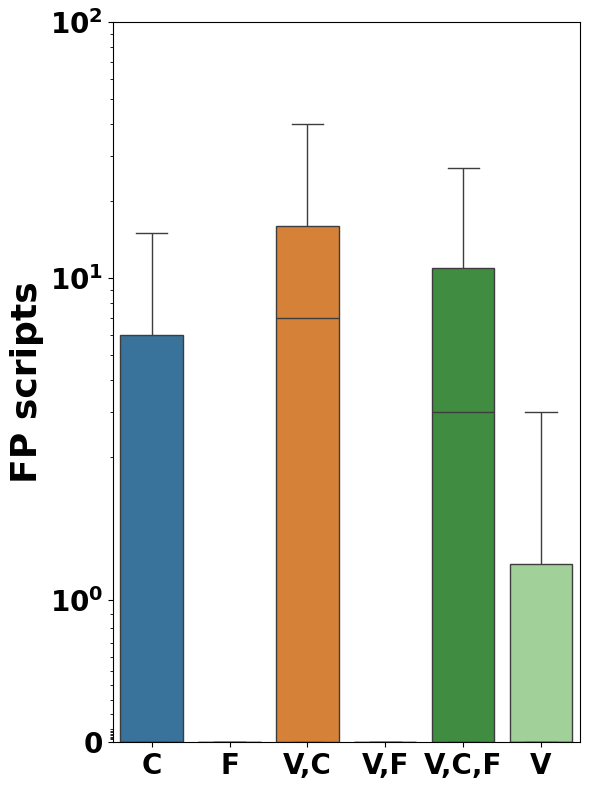


✓ PROCESSING COMPLETE!
→ Plot saved as 'fingerprinting_scripts_class_groups.pdf'
→ You can now delete all original JavaScript CSV files


/tmp/ipykernel_3404172/872277097.py:252: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bp = sns.boxplot(
/tmp/ipykernel_3404172/872277097.py:271: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes.set_xticklabels(


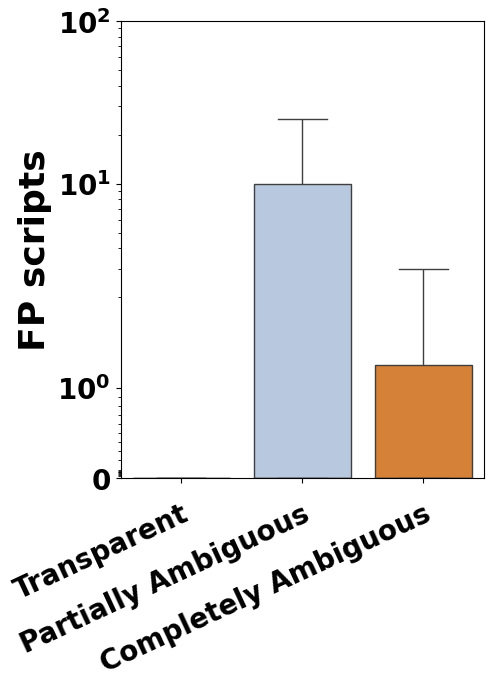

In [12]:

all_scripts_unique = js_from_file
print(f"Total unique scripts across all files: {len(all_scripts_unique)}")

# Assign disclosure group based on class lists
all_scripts_unique['disclosure_group'] = all_scripts_unique['domain'].apply(assign_disclosure_group)

# Map class numbers to readable names (optional)
class_mapping = {
    1: "Class 1", 2: "Class 2", 3: "Class 3", 4: "Class 4",
    5: "Class 5", 6: "Class 6", 7: "Class 7", 8: "Class 8",
    None: "Unassigned"
}
all_scripts_unique['disclosure_group'] = all_scripts_unique['disclosure_group'].map(class_mapping)

# Count scripts per domain
request_counts = all_scripts_unique.groupby(
    ['disclosure_group', 'domain', 'host_url']
).size().reset_index(name='request_count')

combined_data = request_counts.groupby(
    ['disclosure_group', 'domain']
)['request_count'].sum().reset_index(name='total_request_count')

print(f"Domains with scripts: {len(combined_data)}")

# Save intermediate result
combined_data.to_csv("javascript_analysis2_classes.csv", index=False)

# Add missing domains with request_count = 0 for each class
def create_zero_entries(domain_list, class_num):
    missing_domains = list(
        set(domain_list) - set(combined_data[combined_data['disclosure_group'] == f"Class {class_num}"]['domain'])
    )
    return pd.DataFrame({
        'disclosure_group': [f"Class {class_num}"] * len(missing_domains),
        'domain': missing_domains,
        'total_request_count': [0] * len(missing_domains)
    })

zero_entries = pd.concat([
    create_zero_entries(class_1, 1),
    create_zero_entries(class_2, 2),
    create_zero_entries(class_3, 3),
    create_zero_entries(class_4, 4),
    create_zero_entries(class_5, 5),
    create_zero_entries(class_6, 6),
    create_zero_entries(class_7, 7),

], ignore_index=True)

print(f"\nTotal zero entries: {len(zero_entries)}")

# Print zero entries statistics
group_counts = zero_entries['disclosure_group'].value_counts()
print("\nNumber of zero entries per class:")
for group, count in group_counts.items():
    print(f"  - {group}: {count}")

combined_data = pd.concat([combined_data, zero_entries], ignore_index=True)
combined_data_scripts = combined_data.copy()

# Compute descriptive statistics
stats = combined_data.groupby("disclosure_group")["total_request_count"].describe()
stats = stats.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "std": "Std Dev",
    "min": "Min",
    "max": "Max"
})[["count", "Mean", "Std Dev", "Min", "Median", "Max"]]

print("\nDescriptive Statistics:")
print(stats)
# ============================================================
# EXTRA ANALYSIS — COMBINED MEDIANS FOR BROAD GROUPS
# ============================================================

print("\nCombined Median Analysis (Broad Groups):")

# Transparent: Classes 1, 2, 3
transparent_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 1", "Class 2", "Class 3"])
]['total_request_count'].median()

# Partially Ambiguous: Classes 4, 5, 6
partially_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6"])
]['total_request_count'].median()

# Completely Ambiguous: Class 7
complete_median = combined_data[
    combined_data['disclosure_group'] == "Class 7"
]['total_request_count'].median()

# Ambiguous overall: 4,5,6,7
ambiguous_median = combined_data[
    combined_data['disclosure_group'].isin(["Class 4", "Class 5", "Class 6", "Class 7"])
]['total_request_count'].median()

print(f" → Transparent (1,2,3): Median = {transparent_median}")
print(f" → Partially Ambiguous (4,5,6): Median = {partially_median}")
print(f" → Completely Ambiguous (7): Median = {complete_median}")
print(f" → Ambiguous All (4,5,6,7): Median = {ambiguous_median}")
print("============================================================\n")



# Print sorted values for each class
for group in combined_data['disclosure_group'].unique():
    group_values = combined_data[
        combined_data['disclosure_group'] == group
    ]['total_request_count'].sort_values()
    print(f"\n{group} total_request_count values:\n{group_values.values}\n")

# ============================================================
# VISUALIZATION
# ============================================================
plot_data = combined_data[
    ~combined_data['disclosure_group'].isin(["Class 3", "Class 8"])
]
fig, axes = plt.subplots(1, 1, figsize=(6, 8))

order = ["Class 1", "Class 2", "Class 4", "Class 5", "Class 6", "Class 7"]

bp = sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=plot_data,
    order=order,
    palette=colors[:7],
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)

# Customize the plot
axes.set_ylabel("FP scripts", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=20)
axes.set_yscale("symlog")
axes.set_ylim(0, 10**2)

# Modify x-tick labels
xtick_labels = [label.get_text().replace("Class ", "C") for label in axes.get_xticklabels()]
axes.set_xticklabels(
    xtick_labels,
    rotation=0,
    fontsize=20,
    fontweight='bold',
    ha='right'
)



axes.set_xticklabels(
    xtick_labels,
    rotation=0,
    fontsize=20,
    fontweight='bold',
    ha='center'      # keep centered so shift works cleanly
)

# ===== FINAL X-LABEL OVERRIDE (AFTER ALL COMPUTATION) =====
ax = axes   # important: reuse the same axis, NOT plt.gca()

old_labels = [l.get_text() for l in ax.get_xticklabels()]
print("Old order:", old_labels)

new_labels = [
    "C",
    "F",
    "V,C",
    "V,F",
    "V,C,F",
    "V"
]

assert len(old_labels) == len(new_labels), "Label count mismatch!"

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(
    new_labels,
    fontsize=20,
    fontweight="bold"
)


# 🔥 Correct + working right-shift for categorical plots
plt.setp(
    axes.get_xticklabels(),
    x=0.12,           # <-- shift amount (increase/decrease as needed)
    rotation_mode='anchor'
)


for tick in axes.get_xticklabels():
    x, y = tick.get_position()
    tick.set_position((x + 0.05, y))

# Style y-axis ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)

for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

# Set minor ticks for symlog y-axis
axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("fingerprinting_scripts_class_groups.pdf")
plt.show()

print("\n" + "="*60)
print("✓ PROCESSING COMPLETE!")
print("="*60)
print(f"→ Plot saved as 'fingerprinting_scripts_class_groups.pdf'")
# print(f"→ Accumulated data saved in '{INTERMEDIATE_FILE}'")
print(f"→ You can now delete all original JavaScript CSV files")
print("="*60)



# ============================================================
# VISUALIZATION — BROAD 3-GROUP VERSION
# ============================================================

# Map class → broader disclosure group
broad_map = {
    "Class 1": "Transparent",
    "Class 2": "Transparent",
    "Class 3": "Transparent",
    "Class 4": "Partially Ambiguous",
    "Class 5": "Partially Ambiguous",
    "Class 6": "Partially Ambiguous",
    "Class 7": "Completely Ambiguous",
}

# Apply only for classes 1–7
plot_data_broad = plot_data.copy()
plot_data_broad = plot_data_broad[
    plot_data_broad['disclosure_group'] != 'Class 8'
]

plot_data_broad['broad_group'] = plot_data_broad['disclosure_group'].map(broad_map)

# Boxplot with broad groups
fig, axes = plt.subplots(1, 1, figsize=(5, 7))

order_broad = ["Transparent", "Partially Ambiguous", "Completely Ambiguous"]

bp = sns.boxplot(
    x="broad_group",
    y="total_request_count",
    data=plot_data_broad,
    order=order_broad,
    palette=colors[:3],
    showfliers=False,
    saturation=0.65,
    ax=axes,
    orient="v"
)

# Customize the plot
axes.set_ylabel("FP scripts", fontsize=26, fontweight='bold')
axes.set_xlabel("", fontsize=22)
axes.set_yscale("symlog")
axes.set_ylim(0, 10**2)

# Rotate labels + shift down
axes.set_xticklabels(
    order_broad,
    rotation=25,
    fontsize=20,
    fontweight='bold',
    ha='right'
)


# 🔥 Correct + working right-shift for categorical plots
plt.setp(
    axes.get_xticklabels(),
    x=0.12,           # <-- shift amount (increase/decrease as needed)
    rotation_mode='anchor'
)

for label in axes.get_xticklabels():
    x, y = label.get_position()
    label.set_position((x, y - 0.025))

# Style y-ticks
axes.tick_params(axis='y', which='both', left=True, labelsize=20)
for label in axes.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')

axes.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=10))

plt.tight_layout()
plt.savefig("fingerprinting_scripts_broad_groups.pdf")
plt.show()


In [ ]:
# ============================================================
# BROAD-GROUP MEAN STATISTICS
# ============================================================

print("\nBroad-group Mean Analysis:")

# Mean per broad group
broad_means = (
    plot_data_broad
    .groupby("broad_group")["total_request_count"]
    .mean()
)

# Explicit values (for clarity + paper-ready reporting)
transparent_mean = broad_means.get("Transparent", np.nan)
partially_mean = broad_means.get("Partially Ambiguous", np.nan)
complete_mean = broad_means.get("Completely Ambiguous", np.nan)

# Ambiguous = union of partially + completely
ambiguous_mean = plot_data_broad[
    plot_data_broad["broad_group"].isin(
        ["Partially Ambiguous", "Completely Ambiguous"]
    )
]["total_request_count"].mean()

print(f" → Transparent: Mean = {transparent_mean:.3f}")
print(f" → Partially Ambiguous: Mean = {partially_mean:.3f}")
print(f" → Completely Ambiguous: Mean = {complete_mean:.3f}")
print(f" → Ambiguous (Partial + Complete): Mean = {ambiguous_mean:.3f}")
print("============================================================\n")


## PLot color and merge

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np

sns.set_style("white")  # No grid lines, no grey background
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

# Disable both major and minor grid lines explicitly
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.grid.which"] = "both"



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import LogLocator
import numpy as np

# --- Disclosure groups ---
disclosure_order = [
    'Transparent Disclosure',
    'Partially Ambiguous Disclosure',
    'Complete Ambiguous Disclosure',

]
disclosure_labels = {
    'Transparent Disclosure': "Transparent",
    'Partially Ambiguous Disclosure':'Partially Ambiguous',
    'Complete Ambiguous Disclosure':'Complete Ambiguous',
}
colors = plt.cm.tab20.colors
color_map = dict(zip(disclosure_order, colors[:len(disclosure_order)]))

# --- Format function ---
def format_axes(ax, y_max):
    ax.set_ylabel("")
    xtick_labels = [disclosure_labels.get(label.get_text(), label.get_text())
                    for label in ax.get_xticklabels()]
    ax.set_xticklabels(xtick_labels, rotation=50, fontsize=24, fontweight='bold', ha='right')
    ax.tick_params(axis='y', which='both', left=True, labelsize=24)
    for label in ax.get_yticklabels():
        label.set_fontsize(24)
        label.set_fontweight('bold')
    ax.yaxis.set_minor_locator(LogLocator(base=10.0,
                                          subs=np.arange(2, 10) * 0.1, numticks=10))
    ax.set_xlabel("")
    ax.set_ylim(0, y_max)
    ax.set_yscale("symlog")

# --- Create 2 subplots (aligned) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5), sharey=True)

# Shared Y-axis
fig.text(0.04, 0.7, "Number of trackers", va='center', rotation='vertical',
         fontsize=24, fontweight='bold')

# --- Subplot 1: Cookies ---
sns.boxplot(
    x="disclosure_group",
    y="total_cookie_count",
    data=combined_data_cookies,
    order=disclosure_order,
    palette=color_map,
    showfliers=False,
    saturation=0.65,
    ax=axes[0]
)
format_axes(axes[0], 10**4)
# Title inside the plot (top-center)
axes[0].text(0.5, 0.95, "Cookies",
             transform=axes[0].transAxes,
             fontsize=26, fontweight="bold",
             verticalalignment='top',
             horizontalalignment='center')

# --- Subplot 2: FP Scripts ---
sns.boxplot(
    x="disclosure_group",
    y="total_request_count",
    data=combined_data_scripts,
    order=disclosure_order,
    palette=color_map,
    showfliers=False,
    saturation=0.65,
    ax=axes[1]
)
format_axes(axes[1], 10**4)
# Title inside the plot (top-center)
axes[1].text(0.5, 0.95, "FP scripts",
             transform=axes[1].transAxes,
             fontsize=26, fontweight="bold",
             verticalalignment='top',
             horizontalalignment='center')

plt.tight_layout(rect=[0.06, 0.02, 1, 0.98])
plt.savefig("behavior_disclosure.pdf")
plt.show()

## NEW Code


In [8]:
import json
from collections import defaultdict

In [7]:
def extract_domains_from_category(category_list):
    """
    Extract all domains from a nested category structure

    Format:
    [
      {"ServiceName": {"url": ["domain1", "domain2"]}},
      ...
    ]
    """
    domains = set()

    for item in category_list:
        # Each item is a dict with one key (service name)
        for service_name, service_data in item.items():
            # service_data is a dict with URLs as keys and domain lists as values
            for url, domain_list in service_data.items():
                # Add all domains from the list
                domains.update(domain_list)

    return domains

In [8]:
with open('Split_disclosure_output/Transparent.csv', 'r') as file:
    transparent_disclosure = [line.strip() for line in file.readlines()]
with open('Split_disclosure_output/Partially_Ambiguous.csv', 'r') as file:
    partially_ambiguous = [line.strip() for line in file.readlines()]

with open('Split_disclosure_output/Completely_Ambiguous.csv', 'r') as file:
    complete_ambiguous = [line.strip() for line in file.readlines()]

with open('Split_disclosure_output/No_Disclosure.csv', 'r') as file:
    no_disclosure = [line.strip() for line in file.readlines()]




class_1, class_2, class_3, class_4 = [], [], [], []
class_5, class_6, class_7, class_8 = [], [], [], []

base_path = "Split_disclosure_output/class_"

for i in range(1, 8+1):
    file_path = f"{base_path}{i}.csv"

    try:
        with open(file_path, "r") as f:
            lines = [line.strip() for line in f.readlines() if line.strip()]
    except Exception:
        lines = []   # File missing or empty -> ignore safely

    globals()[f"class_{i}"] = lines



In [2]:
with open('total_common_only_domain.csv', 'r') as file:
    common_domains = [line.strip() for line in file.readlines()]
common_domains = set(common_domains)
len(common_domains)

33946

In [54]:
with open('transparent_disclosure_scripts_only_fs.csv', 'r') as file:
    transparent_disclosure_only_js = [line.strip() for line in file.readlines()]
transparent_disclosure_only_js = set(transparent_disclosure_only_js)
len(transparent_disclosure_only_js)

2032

In [56]:
intersection_set = transparent_disclosure_only_js & set(class_2)
print(len(intersection_set))

1934


In [ ]:
# df_javascript = main_map_unique["javascript"]
# df_javascript = df_javascript[df_javascript["clicked"].notna()]
# df_javascript["clicked_stage"] = df_javascript["stage"] + " (" + df_javascript["clicked"].str.capitalize() + ")"
# df_javascript['domain_script_url'] = df_javascript['host_url'].apply(lambda url: tldextract.extract(str(url)).registered_domain if pd.notnull(url) else None)

In [ ]:
# df_cookie = main_map_unique["javascript_cookies"]
# df_cookie = df_cookie[df_cookie["clicked"].notna()]
# df_cookie["clicked_stage"] = df_cookie["stage"] + " (" + df_cookie["clicked"].str.capitalize() + ")"
# df_cookie['domain_cookie'] = df_cookie['host_url'].apply(lambda url: tldextract.extract(url).registered_domain)

In [2]:
import pandas as pd 
df_javascript = pd.read_csv('js_combined.csv')
df_cookie = pd.read_csv('javascript_cookies_combined.csv')

In [5]:
import json

In [9]:
with open('dataset_disconnect/services-relay-disconnect.json', 'r', encoding='utf-8') as f:
    json_data = json.load(f)

    # Extract domains from FingerprintingInvasive and FingerprintingGeneral categories
    fp_invasive_list = json_data.get("categories", {}).get("FingerprintingInvasive", [])
    fp_general_list = json_data.get("categories", {}).get("FingerprintingGeneral", [])

    # Parse the nested structure to extract actual domains
    fp_invasive_domains = extract_domains_from_category(fp_invasive_list)
    fp_general_domains = extract_domains_from_category(fp_general_list)
    df_javascript['FingerprintingInvasive'] = df_javascript['domain_script_url'].isin(fp_invasive_domains)
    df_javascript['FingerprintingGeneral'] = df_javascript['domain_script_url'].isin(fp_general_domains)


In [28]:
df_javascript.head(5)

,visit_id,domain,clicked_stage,domain_script_url,symbol,AllList,host_url,FingerprintingInvasive,FingerprintingGeneral
0,8238312058978,royal.uk,Before Interaction (Reject),royal.uk,Date.getTime,False,https://www.royal.uk/,False,False
1,8238312058978,royal.uk,Before Interaction (Reject),cookiebot.com,Document.cookie,False,https://consent.cookiebot.com/uc.js,False,False
2,8238312058978,royal.uk,Before Interaction (Reject),googletagmanager.com,Navigator.userAgent,True,https://www.googletagmanager.com/gtm.js?id=GTM...,False,False
3,8238312058978,royal.uk,Before Interaction (Reject),cookiebot.com,window.localStorage,False,https://consentcdn.cookiebot.com/sdk/bc-v4.min...,False,False
4,8238312058978,royal.uk,Before Interaction (Reject),royal.uk,Navigator.userAgent,False,https://www.royal.uk/libraries/lazysizes/lazys...,False,False


In [69]:
import json

json_file_path = 'dataset_disconnect/services-relay-disconnect.json'
with open(json_file_path, 'r') as f:
    json_data = json.load(f)

# Step 2: Desired categories
selected_categories = [
    "Email",
    "EmailAggressive",
    "Advertising",
    "Analytics",
    "FingerprintingInvasive",
    "FingerprintingGeneral",
    "Anti-fraud",
    "Social",
    "Cryptomining"
]

# Step 3: Collect all third-party domains
disconnect_domains = set()

categories = json_data.get("categories", {})

for category_name, services_list in categories.items():
    if category_name not in selected_categories:
        continue
    for service_item in services_list:

        for service_name, url_map in service_item.items():

            for url, domains in url_map.items():

                disconnect_domains.update(domains)

print(f"Total domains collected: {len(disconnect_domains)}")
print(disconnect_domains)


Total domains collected: 4050
{'digbro.com', 'tr.line.me', 'barilliance.com', 'pardot.com', 'groceryshopping.net', 'reflow.tv', 'createsend16.com', 'x01.aidata.io', 'createsend9.com', 'open.mkt941.com', 'pages05.net', 'vidazoo.com', 'bridgetrack.com', 'neustar.biz', 'adengage.com', 'open.mkt1365.com', 'criteo.net', 'possibleboats.com', 'snoobi.com', 'unwieldyimpulse.com', 'adimg.net', 'adhigh.net', 'lqcdn.com', 'theweathernetwork.com', 'baitbaseball.com', 'damageddistance.com', 'cloisteredcurve.com', 'unblockia.com', 'open.mkt8628.com', 'crypto-webminer.com', 'qksz.com', 'ltwebstatic.com', 'open.mkt6478.com', 'lytics.io', 'micpn.com', 'adscience.nl', 'cityrobotflower.com', 'genesismedia.com', 'opulentsylvan.com', 'yandex.ru/clck/counter', 'game-advertising-online.com', 'byroundprince.com', 'glammedia.com', 'cmail6.com', 'kanoodle.com', 'roia.biz', 'convergedirect.com', 'designbloxlive.com', 'addme.com', 'changeablecats.com', 'iponweb.com', 'cm-mx.advolve.io', 'createsend3.com', 'combbi

In [16]:
df_cookie = df_1.loc[df_1['clicked_stage'].eq("After (Reject)")]

In [17]:

# # Step 1: Get domains with tracking cookies after Reject
# df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
#     'After Interaction (Reject)'
# ])]
df_cookie = df_cookie[
    (df_cookie['domain_cookie'] != df_cookie['domain'])
]
domains_with_tracking_cookies = set(df_cookie['domain'])



In [20]:
print(domains_with_tracking_cookies)

set()


In [ ]:
# import pandas as pd

# output_file = "domains_with_tracking_cookies_after_reject.csv"

# df = pd.DataFrame(
#     sorted(domains_with_tracking_cookies),
#     columns=["domain"]
# )

# df.to_csv(output_file, index=False)

In [ ]:
# import os
# import pandas as pd

# output_file = "domains_with_tracking_cookies_after_reject.csv"

# new_df = pd.DataFrame(
#     sorted(domains_with_tracking_cookies),
#     columns=["domain"]
# )

# if os.path.exists(output_file):
#     old_df = pd.read_csv(output_file)
#     combined = pd.concat([old_df, new_df], ignore_index=True)
#     combined = combined.drop_duplicates(subset=["domain"])
# else:
#     combined = new_df

# combined.to_csv(output_file, index=False)


In [ ]:
# domains_with_tracking_cookies = set(
#     pd.read_csv("domains_with_tracking_cookies_after_reject.csv")["domain"]
# )


In [18]:
common_domains = pd.read_csv('total_common_only_domain.csv')

# Convert first column to a set
common_domains = set(common_domains.iloc[:, 0])

In [19]:
print(len(domains_with_tracking_cookies))

0


In [73]:
domains_without_tracking_cookies = common_domains - domains_with_tracking_cookies
print(len(domains_without_tracking_cookies))

713


In [78]:
df_javascript = df_javascript[
    (df_javascript['AllList'] == True) &
    ((df_javascript['FingerprintingInvasive'] == True) | (df_javascript['FingerprintingGeneral'] == True)) &
    (df_javascript['domain_script_url'] != df_javascript['domain']) 
]

In [79]:
domains_with_fingerprinting_scripts = set(df_javascript['domain'])
print(len(domains_with_fingerprinting_scripts))

21205


In [81]:
domain_with_only_fs = domains_with_fingerprinting_scripts & domains_without_tracking_cookies

df_javascript = df_javascript[
    df_javascript['domain'].isin(domain_with_only_fs)
]

             domain                clicked_stage  count
0  aboutcookies.org   After Interaction (Accept)      2
1  aboutcookies.org   After Interaction (Reject)      1
2  aboutcookies.org  Before Interaction (Accept)      2
3  aboutcookies.org  Before Interaction (Reject)      1
4       afrinic.net   After Interaction (Accept)      2
5           ansa.it   After Interaction (Accept)      8
6           ansa.it  Before Interaction (Accept)      4
7       bilibili.tv   After Interaction (Accept)      4
8       bilibili.tv  Before Interaction (Accept)      4
9       binance.com   After Interaction (Accept)      2
                 clicked_stage
0   After Interaction (Accept)
1  Before Interaction (Accept)
2  Before Interaction (Reject)
3   After Interaction (Reject)
                 clicked_stage  key
0   After Interaction (Accept)    1
1  Before Interaction (Accept)    1
2  Before Interaction (Reject)    1
3   After Interaction (Reject)    1

===== Statistical Summary for Each Stage =====JS

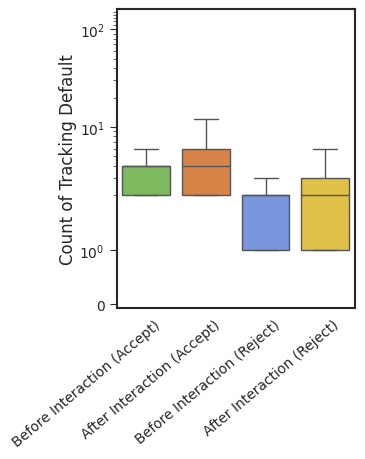

In [85]:
boxplot_tracking_stages(df_javascript, FIG_NAME="Default")

In [ ]:
def assign_disclosure_group(domain):
    if domain in transparent_disclosure:
        return 'Transparent Disclosure'
    elif domain in partially_ambiguous:
        return 'Partially Ambiguous Disclosure'
    elif domain in complete_ambiguous:
        return 'Complete Ambiguous Disclosure'
    elif domain in no_disclosure:
        return 'No Disclosure'

In [36]:
# Step 5: Assign disclosure group

# Step 6: Group domains by disclosure type
grouped_domains_xx = defaultdict(list)
for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    grouped_domains_xx[group].append(domain)

# Step X5: Print counts
print("\nNumber of sites with no tracking cookies:")
for group in ['Transparent Disclosure', 'Partially Ambiguous Disclosure', 'Complete Ambiguous Disclosure','No Disclosure']:
    count = len(grouped_domains_xx[group])
    print(f"{group}: {count}")



Number of sites with no tracking cookies:
Transparent Disclosure: 14496
Partially Ambiguous Disclosure: 10148
Complete Ambiguous Disclosure: 235
No Disclosure: 501


In [26]:
df_javascript.head(5)

,visit_id,domain,clicked_stage,domain_script_url,symbol,AllList,host_url
0,8238312058978,royal.uk,Before Interaction (Reject),royal.uk,Date.getTime,False,https://www.royal.uk/
1,8238312058978,royal.uk,Before Interaction (Reject),cookiebot.com,Document.cookie,False,https://consent.cookiebot.com/uc.js
2,8238312058978,royal.uk,Before Interaction (Reject),googletagmanager.com,Navigator.userAgent,True,https://www.googletagmanager.com/gtm.js?id=GTM...
3,8238312058978,royal.uk,Before Interaction (Reject),cookiebot.com,window.localStorage,False,https://consentcdn.cookiebot.com/sdk/bc-v4.min...
4,8238312058978,royal.uk,Before Interaction (Reject),royal.uk,Navigator.userAgent,False,https://www.royal.uk/libraries/lazysizes/lazys...


In [31]:
# Step X1: Filter fingerprinting scripts after Reject stages (as you defined)
df_javascript_reject = df_javascript[df_javascript['clicked_stage'].isin([
    'After Interaction (Reject)',
])]
df_javascript_reject = df_javascript_reject[
    (df_javascript_reject['AllList'] == True) &
    ((df_javascript_reject['FingerprintingInvasive'] == True) | (df_javascript_reject['FingerprintingGeneral'] == True)) &
    (df_javascript_reject['domain_script_url'] != df_javascript_reject['domain']) 
]

# Step X2: Get domains with JavaScript-based fingerprinting
domains_with_fingerprinting_scripts = set(df_javascript_reject['domain'])
print(len(domains_with_fingerprinting_scripts))

11134


In [ ]:
domain_with_only_fs = domains_with_fingerprinting_scripts & domains_without_cookies

In [ ]:
# import os
# import pandas as pd

# output_file = "domains_with_fingerprints_after_reject.csv"

# new_df = pd.DataFrame(
#     sorted(domains_with_fingerprinting_scripts),
#     columns=["domain"]
# )

# if os.path.exists(output_file):
#     old_df = pd.read_csv(output_file)
#     combined = pd.concat([old_df, new_df], ignore_index=True)
#     combined = combined.drop_duplicates(subset=["domain"])
# else:
#     combined = new_df

# combined.to_csv(output_file, index=False)

In [ ]:
# domains_with_fingerprinting_scripts = set(
#     pd.read_csv("domains_with_fingerprints_after_reject.csv")["domain"]
# )


In [ ]:
# print(len(domains_with_fingerprinting_scripts))

In [53]:

# Step X3: Intersect with domains that have no tracking cookies
import csv
domains_with_scripts_only = domains_without_tracking_cookies & domains_with_fingerprinting_scripts

# Step X4: Group by disclosure type
grouped_script_domains = defaultdict(list)
for domain in domains_with_scripts_only:
    group = assign_disclosure_group(domain)
    grouped_script_domains[group].append(domain)

# Step X5: Print counts
print("\nNumber of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:")
for group in [
    'Transparent Disclosure',
    'Partially Ambiguous Disclosure',
    'Complete Ambiguous Disclosure',
    'No Disclosure'
]:
    count = len(grouped_script_domains[group])
    print(f"{group}: {count}")

    # ✅ Export ONLY Transparent Disclosure to CSV
    if group == 'Transparent Disclosure':
        output_file = "transparent_disclosure_scripts_only_fs.csv"

        with open(output_file, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["domain"])

            for domain in grouped_script_domains[group]:
                writer.writerow([domain])

        print(f"Saved: {output_file}")


Number of sites with fingerprinting scripts but no tracking cookies after Reject, grouped by disclosure type:
Transparent Disclosure: 2032
Saved: transparent_disclosure_scripts_only_fs.csv
Partially Ambiguous Disclosure: 2476
Complete Ambiguous Disclosure: 40
No Disclosure: 33


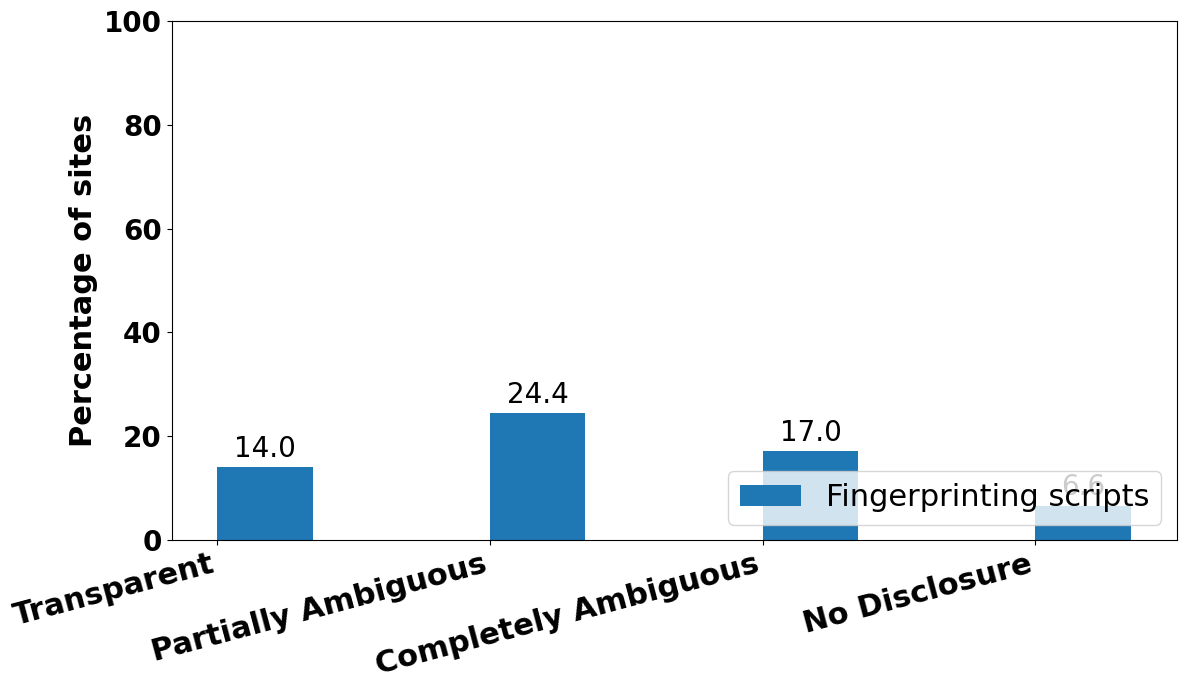

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Define relevant disclosure groups
disclosure_groups = ['Transparent Disclosure', 'Partially Ambiguous Disclosure', 'Complete Ambiguous Disclosure','No Disclosure']

# Count total domains without tracking cookies in each disclosure group
group_total = defaultdict(int)
for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    if group in disclosure_groups:
        group_total[group] += 1

# Calculate script percentages relative to domains without cookies in each group
script_percentages = []

for group in disclosure_groups:
    total = group_total[group]
    script_count = len(grouped_script_domains[group])

    script_percent = (script_count / total * 100) if total > 0 else 0

    script_percentages.append(script_percent)

# Plotting
x = np.arange(len(disclosure_groups))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars2 = ax.bar(x + width/2, script_percentages, width, label='Fingerprinting scripts')

ax.bar_label(bars2, fmt='%.1f', padding=3, fontsize=20)

# Set labels and titles with fontsize
ax.set_ylabel('Percentage of sites', fontsize=22, fontweight='bold')
# ax.set_title('Tracking requests vs fingerprinting scripts\n(no cookies after Reject)', fontsize=16)
ax.set_xticks(x)
ax.set_ylim(0,100)
ax.set_xticklabels(disclosure_groups, rotation=15, fontsize=16, ha = "right")
ax.tick_params(axis='y', labelsize=16)
for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight('bold')
xtick_labels = [
    label.get_text()
    .replace("Transparent Disclosure", "Transparent")
    .replace("Partially Ambiguous Disclosure", "Partially Ambiguous")
    .replace("Complete Ambiguous Disclosure", "Completely Ambiguous")
    .replace("No Disclosure", "No Disclosure")
    for label in ax.get_xticklabels()
]
ax.set_xticklabels(xtick_labels, rotation=15, fontsize=22, ha="right")

ax.legend(fontsize=22, loc = 'lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("sites_still_tracking_after_reject.pdf")

plt.show()

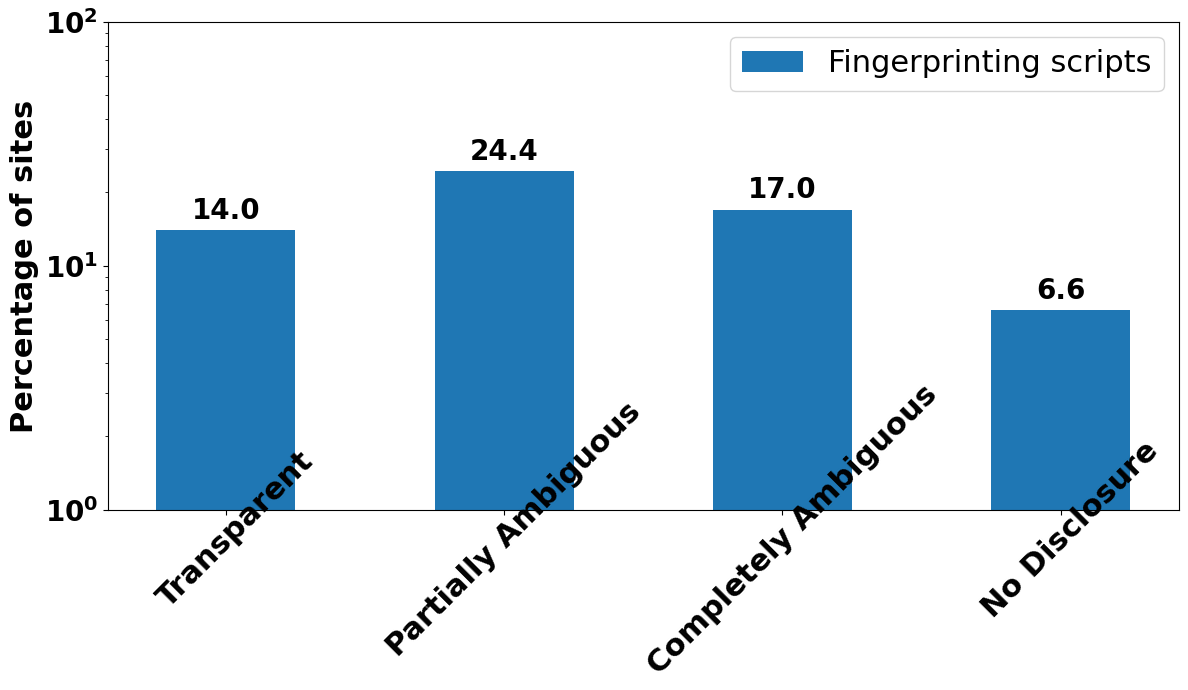

In [42]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ============================================================
# Define relevant disclosure groups (BROAD)
# ============================================================
disclosure_groups = [
    'Transparent Disclosure',
    'Partially Ambiguous Disclosure',
    'Complete Ambiguous Disclosure',
    'No Disclosure'
]

# ============================================================
# Count total domains without tracking cookies in each group
# ============================================================
group_total = defaultdict(int)

for domain in domains_without_tracking_cookies:
    group = assign_disclosure_group(domain)
    if group in disclosure_groups:
        group_total[group] += 1

# ============================================================
# Calculate fingerprinting script percentages
# ============================================================
script_percentages = []

for group in disclosure_groups:
    total = group_total[group]
    script_count = len(grouped_script_domains[group])

    script_percent = (script_count / total * 100) if total > 0 else 0
    script_percentages.append(script_percent)

# ============================================================
# Plotting — ONLY Fingerprinting Scripts
# ============================================================
x = np.arange(len(disclosure_groups))
width = 0.5

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    x,
    script_percentages,
    width,
    label='Fingerprinting scripts'
)

# Value labels
ax.bar_label(
    bars,
    fmt='%.1f',
    padding=4,
    fontsize=20,
    fontweight='bold'
)

# Y-axis (log scale)
ax.set_ylabel('Percentage of sites', fontsize=22, fontweight='bold')
ax.set_yscale('log')
ax.set_ylim(1, 100)   # log scale cannot include 0
ax.tick_params(axis='y', labelsize=20)

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


# X-axis labels (clean + readable)
xtick_labels = [
    "Transparent",
    "Partially Ambiguous",
    "Completely Ambiguous",
    "No Disclosure"
]

ax.set_xticks(x)
ax.set_xticklabels(
    xtick_labels,
    fontsize=22,
    fontweight='bold',
    ha='center',
    rotation=45,
    rotation_mode='anchor'
)

# Legend
ax.legend(fontsize=22, loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig("sites_still_tracking_after_reject.pdf")
plt.show()


In [ ]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
import numpy as np

# ============================================================
# ✏️  TWEAK THESE PARAMETERS
# ============================================================
BAR_WIDTH     = 0.35   # width of each bar (0.1 = very thin, 0.8 = very wide)
BAR_SPACING   = 1.0    # distance between bar centres (1.0 = default, >1 = more gap, <1 = tighter)
# ============================================================

# ── Data ─────────────────────────────────────────────────────────────────────
labels = ["Transparent", "Partially\nAmbiguous", "Completely\nAmbiguous", "No Disclosure"]
values = [14.0, 24.4, 17.0, 6.6]

# ── Style constants ───────────────────────────────────────────────────────────
FONT_FAMILY = "DejaVu Sans"
BAR_COLOR   = "#2166AC"
EDGE_COLOR  = "#154F80"
GRID_COLOR  = "#CCCCCC"
TEXT_COLOR  = "#1A1A1A"

plt.rcParams.update({
    "font.family":        FONT_FAMILY,
    "text.color":         TEXT_COLOR,
    "axes.labelcolor":    TEXT_COLOR,
    "xtick.color":        TEXT_COLOR,
    "ytick.color":        TEXT_COLOR,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "pdf.fonttype":       42,   # embed fonts — required by most journals
    "ps.fonttype":        42,
})

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.2, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# BAR_SPACING controls the x-positions of bars
x = np.arange(len(labels)) * BAR_SPACING

bars = ax.bar(
    x, values, BAR_WIDTH,
    color=BAR_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    zorder=3,
)

# ── Value labels ──────────────────────────────────────────────────────────────
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.12,
        f"{val:.1f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold",
        color=TEXT_COLOR,
    )

# ── Y-axis (log scale) ────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(1, 100)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y)}"))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.tick_params(axis="y", which="major", labelsize=10, length=4, width=0.8)
ax.tick_params(axis="y", which="minor", length=2.5, width=0.6)
ax.yaxis.grid(True, which="major", color=GRID_COLOR, linewidth=0.6,
              linestyle="--", zorder=0)
ax.set_axisbelow(True)

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, fontweight="bold", color=TEXT_COLOR,
                   linespacing=1.3)
ax.tick_params(axis="x", length=0)

# Extend x-axis margins so bars don't hug the edges
ax.set_xlim(-BAR_SPACING * 0.6, x[-1] + BAR_SPACING * 0.6)

# ── Axis label ────────────────────────────────────────────────────────────────
ax.set_ylabel("Percentage of sites (%)", fontsize=11, fontweight="bold", labelpad=8)

# ── Spines ────────────────────────────────────────────────────────────────────
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(0.9)
    ax.spines[spine].set_color("#555555")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handle = mpatches.Patch(facecolor=BAR_COLOR, edgecolor=EDGE_COLOR,
                                linewidth=0.7, label="Fingerprinting scripts")
ax.legend(
    handles=[legend_handle],
    fontsize=10,
    loc="upper right",
    frameon=True,
    framealpha=0.95,
    edgecolor="#AAAAAA",
    fancybox=False,
)

plt.tight_layout(pad=1.1)
plt.show()
plt.savefig("fingerprinting_chart.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fingerprinting_chart.png", dpi=300, bbox_inches="tight", facecolor="white")
print("Saved: fingerprinting_chart.pdf / .png")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches ###########################
import numpy as np

# ============================================================
# ✏️  TWEAK THESE PARAMETERS
# ============================================================
BAR_WIDTH     = 0.35   # width of each bar (0.1 = very thin, 0.8 = very wide)
BAR_SPACING   = 1.0    # distance between bar centres (1.0 = default, >1 = more gap, <1 = tighter)
# ============================================================

# ── Data ─────────────────────────────────────────────────────────────────────
labels = ["Transparent", "Partially\nAmbiguous", "Completely\nAmbiguous", "No Disclosure"]
values = [14.0, 24.4, 17.0, 6.6]

# ── Style constants ───────────────────────────────────────────────────────────
FONT_FAMILY  = "DejaVu Sans"
BAR_COLOR    = "#2166AC"
EDGE_COLOR   = "#154F80"
GRID_COLOR   = "#CCCCCC"
TEXT_COLOR   = "#1A1A1A"
SPINE_COLOR  = "#555555"

plt.rcParams.update({
    "font.family":        FONT_FAMILY,
    "text.color":         TEXT_COLOR,
    "axes.labelcolor":    TEXT_COLOR,
    "xtick.color":        TEXT_COLOR,
    "ytick.color":        TEXT_COLOR,
    # All four spines ON — gives a clean closed boundary box
    "axes.spines.top":    True,
    "axes.spines.right":  True,
    "axes.spines.left":   True,
    "axes.spines.bottom": True,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
})

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.2, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(labels)) * BAR_SPACING

bars = ax.bar(
    x, values, BAR_WIDTH,
    color=BAR_COLOR,
    edgecolor=EDGE_COLOR,
    linewidth=0.7,
    zorder=3,
)

# ── Value labels ──────────────────────────────────────────────────────────────
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.12,
        f"{val:.1f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold",
        color=TEXT_COLOR,
    )

# ── Y-axis (log scale) ────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(1, 100)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{int(y)}"))
ax.yaxis.set_minor_formatter(ticker.NullFormatter())
ax.tick_params(axis="y", which="major", labelsize=10, length=4, width=0.8)
ax.tick_params(axis="y", which="minor", length=2.5, width=0.6)
ax.yaxis.grid(True, which="major", color=GRID_COLOR, linewidth=0.6,
              linestyle="--", zorder=0)
ax.set_axisbelow(True)

# ── X-axis ────────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, fontweight="bold", color=TEXT_COLOR,
                   linespacing=1.3)
ax.tick_params(axis="x", length=0)

ax.set_xlim(-BAR_SPACING * 0.6, x[-1] + BAR_SPACING * 0.6)

# ── Axis label ────────────────────────────────────────────────────────────────
ax.set_ylabel("Percentage of sites (%)", fontsize=11, fontweight="bold", labelpad=8)

# ── All four spines — uniform weight for a tidy closed box ───────────────────
for spine in ax.spines.values():
    spine.set_linewidth(0.9)
    spine.set_color(SPINE_COLOR)

# No tick marks on top/right (labels only on left/bottom)
ax.tick_params(top=False, right=False)

# # ── Legend ────────────────────────────────────────────────────────────────────
# legend_handle = mpatches.Patch(facecolor=BAR_COLOR, edgecolor=EDGE_COLOR,
#                                 linewidth=0.7, label="Fingerprinting scripts")
# ax.legend(
#     handles=[legend_handle],
#     fontsize=10,
#     loc="upper right",
#     frameon=True,
#     framealpha=0.95,
#     edgecolor="#AAAAAA",
#     fancybox=False,
# )

plt.tight_layout(pad=1.1)

# ── Preview in terminal — comment out if running headless ────────────────────
plt.show()

# ── Save ─────────────────────────────────────────────────────────────────────
plt.savefig("fingerprinting_chart.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("fingerprinting_chart.png", dpi=300, bbox_inches="tight", facecolor="white")
print("Saved: fingerprinting_chart.pdf / .png")


Saved: fingerprinting_chart.pdf / .png


# top 20

In [57]:
# # Step 1: Get domains with tracking cookies after Reject
# df_cookie_reject = df_cookie[df_cookie['clicked_stage'].isin([
#     'Before Interaction (Reject)',
#     'After Interaction (Reject)',
#     'After Reload (Reject)'
# ])]
# df_cookie_reject = df_cookie_reject[
#     (df_cookie_reject['is_tracking'] == True) &
#     (df_cookie_reject['domain_cookie'] != df_cookie_reject['domain'])
# ]
# domains_with_tracking_cookies = set(df_cookie_reject['domain'])

# # Step 2: Get domains with third-party tracking requests after Reject

# df_request_reject = df_request[df_request['clicked_stage'].isin([
#     'Before Interaction (Reject)',
#     'After Interaction (Reject)',
#     'After Reload (Reject)'
# ])]

# df_request_tracking_reject = df_request_reject[
#     (df_request_reject['AllList'] == True) &
#     (df_request_reject['domain_url'] != df_request_reject['domain'])
#     & (df_request_reject['domain_url'].isin(disconnect_domains))
# ]

# # df_request_tracking_reject = df_request_tracking_reject['domain_url'].isin(disconnect_domains)

# domains_with_tracking_requests = set(df_request_tracking_reject['domain'])

# # Step 3: Domains that have no tracking cookies
# domains_without_tracking_cookies = common_domains - domains_with_tracking_cookies

print(len(domains_without_tracking_cookies))

# Step 4: Filter to those that still have tracking requests
domains_with_fs_only = domains_without_tracking_cookies & domains_with_fingerprinting_scripts
len(domains_with_fs_only)


25380


4581

In [59]:
# Step 5: Filter requests on domains_with_requests_only
filtered_df = df_javascript_reject[df_javascript_reject['domain'].isin(domains_with_fs_only)]

tracking_to_domains = defaultdict(set)

for _, row in filtered_df.iterrows():
    tracking_to_domains[row['domain_script_url']].add(row['domain'])

# Step 7: Count how many unique websites each tracking domain appears on
tracking_domain_counts = {tracker: len(domains) for tracker, domains in tracking_to_domains.items()}

# Step 8: Get top 20 tracking domains by number of websites
top_20 = sorted(tracking_domain_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# Step 9: Display in DataFrame
top_20_df = pd.DataFrame(top_20, columns=['Tracking Domain', 'Number of Websites'])
print(top_20_df)
# top_20_df.to_csv("top20.csv", index = False)

          Tracking Domain  Number of Websites
0   googlesyndication.com                2051
1            facebook.net                1653
2         doubleclick.net                1577
3    google-analytics.com                1368
4   googletagservices.com                 266
5           crwdcntrl.net                 255
6           fastclick.net                 208
7        doubleverify.com                 118
8              adsrvr.org                 104
9               dwin1.com                  56
10         clickcease.com                  55
11    adsafeprotected.com                  49
12     bounceexchange.com                  42
13   googleadservices.com                  39
14               2mdn.net                  32
15           leadinfo.net                  22
16          albacross.com                  13
17           openfpcdn.io                  12
18          perfdrive.com                  11
19              adtng.com                  10


In [74]:
json_file_path = 'disconnect-tracking-protection/entities.json'
with open(json_file_path, 'r') as f:
    entities = json.load(f)

entities = entities["entities"]

# Build reverse mapping: domain -> company
domain_to_company = {}
for company, data in entities.items():
    for domain in data.get("properties", []):
        domain_to_company[domain] = company
    for domain in data.get("resources", []):
        domain_to_company[domain] = company
domain_to_company["googletagmanager.com"] = "Google"


# Step 4: Map each tracking domain_url to set of first-party domains it appears on
tracking_to_domains = defaultdict(set)
for _, row in filtered_df.iterrows():
    tracking_to_domains[row['domain_script_url']].add(row['domain'])

# Step 5: Map companies to unique first-party domains
company_to_domains = defaultdict(set)
for tracker_domain, domain_set in tracking_to_domains.items():
    company = domain_to_company.get(tracker_domain, tracker_domain)
    company_to_domains[company].update(domain_set)

# Step 6: Count unique websites per company
company_counts = {company: len(domains) for company, domains in company_to_domains.items()}

# Step 7: Get top 20 companies
top_20_companies = sorted(company_counts.items(), key=lambda x: x[1], reverse=True)[:20]

# Step 8: Display and save results
top_20_companies_df = pd.DataFrame(top_20_companies, columns=['Company', 'Number of Websites'])
print(top_20_companies_df)
# top_20_companies_df.to_csv("top20_companies.csv", index=False)

# Load CSVs
top20_domains_df = top_20_df  # Columns: Tracking Domain, Number of Websites
top20_companies_df = top_20_companies_df  # Columns: Company, Number of Websites

# Build domain-to-company map
domain_to_company = {
    domain: company
    for company, data in entities.items()
    for domain in data.get("properties", []) + data.get("resources", [])
}
domain_to_company["googletagmanager.com"] = "Google"  # Manual fix

# Map company names to tracking domains
top20_domains_df["Company"] = top20_domains_df["Tracking Domain"].map(domain_to_company)

# Calculate percentages
total = 4581  # Predefined value
print(total)
top20_domains_df["Percentage"] = (top20_domains_df["Number of Websites"] / total) * 100
top20_companies_df["Percentage"] = (top20_companies_df["Number of Websites"] / total) * 100
plt.style.use('default')  # remove seaborn/ggplot background
# Assign consistent colors to companies
all_companies = pd.concat([
    top20_domains_df["Company"],
    top20_companies_df["Company"]
]).dropna().unique()
color_palette = plt.cm.tab20.colors
company_colors = {company: color for company, color in zip(all_companies, color_palette)}
domain_colors = top20_domains_df["Company"].map(company_colors)
company_colors_bar = top20_companies_df["Company"].map(company_colors)
# ═══════════════════════════════════════════════════════════════════════════════
# DROP-IN REPLACEMENT for the two plt.figure(...) plotting blocks in your script.
# Both plots now use the same log scale approach (consistent + clean).
# Fix summary:
#   Plot 1 (Domains):   log scale, ylim=(0.1, 200) — same treatment as companies
#   Plot 2 (Companies): log scale, ylim=(0.1, 200) — labels stay inside box
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.ticker as ticker   # add alongside your existing imports
 
 
# ── PLOT 1: Tracking Domains ──────────────────────────────────────────────────
plt.figure(figsize=(14, 7))
ax = plt.gca()
 
ax.grid(False)
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
 
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")
 
x1 = np.arange(len(top20_domains_df))
bars1 = plt.bar(x1, top20_domains_df["Percentage"], color=domain_colors)
 
plt.bar_label(bars1, fmt="%.1f", padding=3, fontsize=15)
plt.ylabel("Percentage of sites", fontsize=20, fontweight="bold")
plt.xticks(x1, top20_domains_df["Tracking Domain"], rotation=65, ha='right')
 
# ── log scale, same as companies graph ───────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(0.1, 200)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
ax.tick_params(axis="y", which="minor", length=3, width=0.8)
# ─────────────────────────────────────────────────────────────────────────────
 
plt.text(0.38, 0.95, "Tracking Domains", transform=ax.transAxes,
         fontsize=32, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
 
for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
 
plt.tight_layout()
plt.savefig("top20_tracking_domains_percent.pdf")
plt.show()


# ── PLOT 2: Tracking Companies ────────────────────────────────────────────────
plt.figure(figsize=(14, 7))
ax = plt.gca()

ax.grid(False)
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.5)
    spine.set_color("black")

x2 = np.arange(len(top20_companies_df))
bars2 = plt.bar(x2, top20_companies_df["Percentage"], color=company_colors_bar)

plt.bar_label(bars2, fmt="%.1f", padding=3, fontsize=16)
plt.ylabel("Percentage of sites", fontsize=20, fontweight="bold")
plt.xticks(x2, top20_companies_df["Company"], rotation=65, ha='right')

# ── log scale, ylim raised so 72.1 label sits inside the box ─────────────────
ax.set_yscale("log")
ax.set_ylim(0.1, 200)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f"{y:g}"))
ax.tick_params(axis="y", which="minor", length=3, width=0.8)
# ─────────────────────────────────────────────────────────────────────────────

plt.text(0.32, 0.95, "Tracking Companies", transform=ax.transAxes,
         fontsize=32, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

for label in ax.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("top20_tracking_companies_percent.pdf")
plt.show()


# plt.figure(figsize=(14, 7))
# ax = plt.gca()

# # Remove grid and background
# ax.grid(False)
# ax.set_facecolor("white")
# plt.gcf().patch.set_facecolor("white")

# # Make full border visible and bold
# for spine in ax.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.5)
#     spine.set_color("black")


# x1 = np.arange(len(top20_domains_df))
# bars1 = plt.bar(x1, top20_domains_df["Percentage"], color=domain_colors)

# plt.bar_label(bars1, fmt="%.1f", padding=3, fontsize=18)
# plt.ylabel("Percentage of sites", fontsize=20, fontweight="bold")
# plt.xticks(x1, top20_domains_df["Tracking Domain"], rotation=65, ha='right')
# plt.ylim(0, 90)

# plt.text(0.38, 0.95, "Tracking Domains", transform=plt.gca().transAxes,
#          fontsize=32, fontweight="bold", va='top', ha='left',
#          bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# for label in plt.gca().get_yticklabels():
#     label.set_fontsize(20)
#     label.set_fontweight("bold")
# for label in plt.gca().get_xticklabels():
#     label.set_fontsize(20)
#     label.set_fontweight("bold")

# plt.tight_layout()
# plt.savefig("top20_tracking_domains_percent.pdf")
# plt.show()



# plt.figure(figsize=(14, 7))
# ax = plt.gca()

# # Remove grid and background
# ax.grid(False)
# ax.set_facecolor("white")
# plt.gcf().patch.set_facecolor("white")

# # Make full border visible and bold
# for spine in ax.spines.values():
#     spine.set_visible(True)
#     spine.set_linewidth(1.5)
#     spine.set_color("black")


# x2 = np.arange(len(top20_companies_df))
# bars2 = plt.bar(x2, top20_companies_df["Percentage"], color=company_colors_bar)

# plt.bar_label(bars2, fmt="%.1f", padding=3, fontsize=18)
# plt.ylabel("Percentage of sites", fontsize=20, fontweight="bold")
# plt.xticks(x2, top20_companies_df["Company"], rotation=65, ha='right')
# plt.ylim(0, 90)

# plt.text(0.32, 0.95, "Tracking Companies", transform=plt.gca().transAxes,
#          fontsize=32, fontweight="bold", va='top', ha='left',
#          bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# for label in plt.gca().get_yticklabels():
#     label.set_fontsize(20)
#     label.set_fontweight("bold")
# for label in plt.gca().get_xticklabels():
#     label.set_fontsize(20)
#     label.set_fontweight("bold")

# plt.tight_layout()
# plt.savefig("top20_tracking_companies_percent.pdf")
# plt.show()

                   Company  Number of Websites
0                   Google                3305
1                     Meta                1653
2                   Lotame                 255
3           PublicisGroupe                 208
4             DoubleVerify                 118
5           The Trade Desk                 104
6                     CHEQ                  71
7                     Awin                  56
8      Integral Ad Science                  49
9               Wunderkind                  42
10           FingerprintJS                  25
11                LeadInfo                  22
12               Albacross                  13
13                   Adobe                  12
14                 Radware                  11
15  EthicalCapitalPartners                  10
16               Trendemon                   9
17                 Emplifi                   7
18              ClickGuard                   7
19             flixcdn.com                   7
4581


In [ ]:
# Step 10: Sample 50 host_urls per tracking domain (from different domains)
sampled_host_urls = []

# Ensure we're only working with filtered requests (from relevant domains)
for tracker in top_20_df['Tracking Domain']:
    # Get all requests where this tracker appears
    tracker_requests = filtered_requests[filtered_requests['domain_url'] == tracker]

    # Group by first-party domain to ensure uniqueness
    grouped = tracker_requests.groupby('domain')

    # From each unique domain, randomly select one host_url
    one_per_domain = grouped.apply(lambda g: g.sample(1)).reset_index(drop=True)

    # Randomly pick 50 of them if more than 50 domains exist
    if len(one_per_domain) > 50:
        sampled = one_per_domain.sample(50, random_state=42)
    else:
        sampled = one_per_domain  # if fewer than 50 domains, take all

    # Add a column to identify the tracker
    sampled['tracking_domain_url'] = tracker

    # Collect the sample
    sampled_host_urls.append(sampled[['tracking_domain_url', 'domain', 'host_url','referrer','headers']])

# Concatenate all samples
final_samples_df = pd.concat(sampled_host_urls, ignore_index=True)

# Save to CSV
final_samples_df.to_csv("top20_sampled_host_urls.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSVs
top20_domains_df = pd.read_csv("top20.csv")  # Columns: Tracking Domain, Number of Websites
top20_companies_df = pd.read_csv("top20_companies.csv")  # Columns: Company, Number of Websites

# Build domain-to-company map
domain_to_company = {
    domain: company
    for company, data in entities.items()
    for domain in data.get("properties", []) + data.get("resources", [])
}
domain_to_company["googletagmanager.com"] = "Google"  # Manual fix

# Map company names to tracking domains
top20_domains_df["Company"] = top20_domains_df["Tracking Domain"].map(domain_to_company)

# Calculate percentages
total = len(domains_without_tracking_cookies)  # Predefined value
print(total)
top20_domains_df["Percentage"] = (top20_domains_df["Number of Websites"] / total) * 100
top20_companies_df["Percentage"] = (top20_companies_df["Number of Websites"] / total) * 100

# Assign consistent colors to companies
all_companies = pd.concat([
    top20_domains_df["Company"],
    top20_companies_df["Company"]
]).dropna().unique()
color_palette = plt.cm.tab20.colors
company_colors = {company: color for company, color in zip(all_companies, color_palette)}
domain_colors = top20_domains_df["Company"].map(company_colors)
company_colors_bar = top20_companies_df["Company"].map(company_colors)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

# Plot top tracking domains
x1 = np.arange(len(top20_domains_df))
bars1 = ax1.bar(x1, top20_domains_df["Percentage"], color=domain_colors)
ax1.bar_label(bars1, fmt="%.1f", padding=3, fontsize=18)
ax1.set_ylabel("Percentage of sites", fontsize=20, fontweight="bold")
ax1.set_xticks(x1)
ax1.set_xticklabels(top20_domains_df["Tracking Domain"], rotation=65, ha='right')
ax1.set_ylim(0, 90)
ax1.text(0.41, 0.95, "Tracking Domains", transform=ax1.transAxes,
         fontsize=24, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Style y-ticks for ax1
for label in ax1.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax1.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

# Plot top tracking companies
x2 = np.arange(len(top20_companies_df))
bars2 = ax2.bar(x2, top20_companies_df["Percentage"], color=company_colors_bar)
ax2.bar_label(bars2, fmt="%.1f", padding=3, fontsize=18)
ax2.set_ylabel("Percentage of sites", fontsize=20, fontweight="bold")
ax2.set_xticks(x2)
ax2.set_xticklabels(top20_companies_df["Company"], rotation=65, ha='right')
ax2.set_ylim(0, 90)
ax2.text(0.41, 0.95, "Tracking Companies", transform=ax2.transAxes,
         fontsize=24, fontweight="bold", va='top', ha='left',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Style y-ticks for ax2
for label in ax2.get_yticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")
for label in ax2.get_xticklabels():
    label.set_fontsize(20)
    label.set_fontweight("bold")

plt.tight_layout()
plt.savefig("top20_domains_and_companies_percent.pdf")
plt.show()
